# CARICOM JUSTICE Model Analysis
## COP31 Climate Negotiations | EPA141A Model-Based Decision Making

**Actor:** CARICOM (Caribbean Community) — Bloc 1: Existential Frontline  
**Welfare function:** SUFFICIENTARIAN (primary) + rival framings (PRIORITARIAN, UTILITARIAN, EGALITARIAN)  
**Key region:** `rcam` (Rest of Central America & Caribbean), benchmarked against major emitters  

---

### Mandate summary
CARICOM represents Caribbean states for whom climate change is an **existential, near-term threat**.  
Core negotiating positions:
- Hold warming to **1.5°C**, anything beyond is a red line
- Demand **Loss and Damage** compensation for harms that exceed adaptation capacity
- Reject equal abatement burden: the Caribbean did not cause the crisis
- Enforce a **sufficiency floor**: no region should be pushed below a basic welfare minimum

### What this notebook produces
1. **Exploratory runs**: BAU vs high-ambition temperature and damage trajectories
2. **Regional equity analysis**: damage burden vs abatement burden across regions
3. **Sufficiency floor analysis**: how BAU erodes Caribbean consumption per capita
4. **Ensemble + sensitivity**: which uncertain dimensions most drive Caribbean outcomes
5. **Scenario discovery**: conditions under which CARICOM falls below the sufficiency floor
6. **Robustness**: which ECR levels keep CARICOM above the floor across all plausible futures
7. **Rival welfare functions**: what UTILITARIAN and other framings sacrifice for the Caribbean
8. **Debate evidence card**: key numbers compiled for the negotiation


## Part 0: Environment setup

This cell loads JUSTICE, sets plotting styles, defines the focus regions, and **constructs the dynamic sufficiency threshold** used throughout the notebook.

### Sufficiency threshold construction

The default JUSTICE sufficiency floor is the global extreme poverty line (~\$1.25/day = 0.456 k USD/cap/yr in 2005 PPP). This is inappropriate for the Caribbean, whose 2024 average consumption per capita is approximately **10.7 k USD/cap/yr** (World Bank). Using the global poverty line would mean the Caribbean never triggers the sufficientarian criterion, even under severe climate damage, a normatively unjustifiable result.

Instead, the threshold is set as **75% of the Caribbean's realistic growth potential**, constructed as follows:

1. Run JUSTICE under **SSP3, ECR = 0.3** (moderate abatement, 30% emission reduction), with **no damage scaling (δ = 1)**. This represents a plausible "potential" growth path with some mitigation effort but no climate damage imposed, and represents what the Caribbean *could* achieve under responsible global action. 
2. Take **75% of that trajectory at each timestep** as the floor. The 75% fraction reflects a capabilities-based interpretation: a region should retain at least three-quarters of its development potential as a basic entitlement, consistent with the principle that sufficiency thresholds should track living standards rather than remain fixed at a poverty line (Wallimann-Helmer & Kräuchi, 2025).

The result is a **dynamic threshold** that rises over time as the baseline economy grows, embodying the argument that "decent living" is not a fixed dollar amount but a moving standard tied to what is achievable.


In [2]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# Locate JUSTICE-main (one level up from the notebook directory) 
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')

_justice_root = os.path.normpath(os.path.join(_NOTEBOOK_DIR, '../JUSTICE-main'))
_PLOTS_DIR    = os.path.join(_NOTEBOOK_DIR, 'plots_caricom')
os.makedirs(_PLOTS_DIR, exist_ok=True)

if _justice_root not in sys.path:
    sys.path.insert(0, _justice_root)
os.chdir(_justice_root)

# Core imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.path as _mpath
import seaborn as sns
from IPython.display import display

# matplotlib deepcopy patch (Python 3.14 compatibility)
def _patched_deepcopy(self, memo=None):
    if memo is None: memo = {}
    new = _mpath.Path.__new__(_mpath.Path)
    memo[id(self)] = new
    verts = self._vertices.copy()
    codes = self._codes.copy() if self._codes is not None else None
    new.__init__(verts, codes, _interpolation_steps=self._interpolation_steps, readonly=False)
    return new
_mpath.Path.__deepcopy__ = _patched_deepcopy

# JUSTICE imports 
from justice.model import JUSTICE
from justice.util.enumerations import WelfareFunction
from justice.util.data_loader import DataLoader
from justice.objectives.objective_functions import years_above_temperature_threshold

# Plot style 
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Caribbean colour palette
C_CARIB   = '#0077B6'   # blue        -> CARICOM / rcam
C_DANGER  = '#D62828'   # red         -> high temperature / danger
C_WARN    = '#F4A261'   # amber       -> warning / moderate
C_SAFE    = '#2DC653'   # green       -> safe / low temperature
C_NEUTRAL = '#6C757D'   # grey        -> background regions
C_EXTRA = '#A1045A'
C_EXTRA2 = "#03FFA7"
C_EXTRA3 = "#FF6F91"
C_EXTRA4 = "#9471FF"
C_EXTRA5 = "#C4FF03"
C_EXTRA6 = "#FF9B03"
C_EXTRA7 = "#230516"

# Data loader: region list
dl = DataLoader()
REGION_LIST = dl.REGION_LIST
N_REGIONS   = len(REGION_LIST)

# CARICOM-relevant region indices
# rcam = Rest of Central America & Caribbean
# rjan57 = Pacific Islands (fellow small island states -> comparison)
# usa, chn, rus = major historical emitters
FOCUS_REGIONS = {
    'rcam'   : 'Caribbean & C. America',
    'rjan57' : 'Pacific Islands',
    'rsaf'   : 'Sub-Saharan Africa',
    'nde'    : 'India',
    'chn'    : 'China',
    'usa'    : 'United States',
    'rus'    : 'Russia',
    'gbr'    : 'United Kingdom',
    'rfa'    : 'Germany',
}

def region_idx(code):
    """Return the integer index of a region code in REGION_LIST."""
    try:
        return list(REGION_LIST).index(code)
    except ValueError:
        # some builds use slightly different lists
        for i, r in enumerate(REGION_LIST):
            if r.lower() == code.lower():
                return i
        raise ValueError(f'Region code {code!r} not found in REGION_LIST')

years = np.arange(2015, 2301)

# Sufficientarian threshold: Caribbean-calibrated
# We reject the default $1.25/day (0.456 k USD/cap/yr) as inappropriate for
# the Caribbean, whose 2024 average CPC is ~10.7 k USD/cap/yr (World Bank).
# Instead we define the threshold as the JUSTICE baseline (2015) CPC for rcam,
# scaled down by the same fraction that the World Bank "lower-middle income"
# floor represents relative to the global median income.
# This gives a dynamic, region-anchored floor rather than a global poverty line.

# ADDITION: Dynamic sufficiency threshold: grows with Caribbean baseline CPC
# Use the BAU no-damage trajectory as the "potential" growth path,
# then take 75% of that at each timestep.
# This means the floor rises as the economy grows. 
# Consistent witha capabilities argument where "decent living" is not a fixed dollar amount.

JUSTICE.hard_reset()
threshold_model = JUSTICE(
    start_year=2015, end_year=2300,
    timestep=1,
    scenario=3,
    climate_ensembles=1, stochastic_run=False,
    social_welfare_function=WelfareFunction.SUFFICIENTARIAN,
)
# Moderate abatement reference -> realistic Caribbean potential
# under SSP3 with some mitigation but no damage scaling
ecr_ref = np.full(threshold_model.emission_control_rate.shape[:2], 0.3)
threshold_model.run(emission_control_rate=ecr_ref, endogenous_savings_rate=True)
ds_base = threshold_model.evaluate()
JUSTICE.hard_reset()

cpc_baseline = np.squeeze(ds_base['consumption_per_capita'])
if cpc_baseline.ndim > 2: cpc_baseline = cpc_baseline[0]

r_carib = list(REGION_LIST).index('rcam')
carib_cpc_2015 = float(cpc_baseline[r_carib, 0])

# 75% of Caribbean's realistic potential trajectory
SUFFICIENCY_THR_DYNAMIC = 0.75 * cpc_baseline[r_carib, :]
SUFFICIENCY_THR = float(SUFFICIENCY_THR_DYNAMIC[0])

print(f'Caribbean CPC at 2015 baseline : {carib_cpc_2015:.4f} k USD/cap/yr')
print(f'Sufficiency threshold at 2015: {SUFFICIENCY_THR:.4f} k USD/cap/yr')
print(f'  (~${SUFFICIENCY_THR * 1e3 / 365.25:.2f}/day in 2005 PPP)')
print(f'Sufficiency threshold at 2100: {SUFFICIENCY_THR_DYNAMIC[2100-2015]:.4f} k USD/cap/yr')

print('Environment ready')
print(f'   JUSTICE root : {_justice_root}')
print(f'   Regions      : {N_REGIONS}')
print(f'   Plots dir    : {_PLOTS_DIR}')

Caribbean CPC at 2015 baseline : 7.5800 k USD/cap/yr
Sufficiency threshold at 2015: 5.6850 k USD/cap/yr
  (~$15.56/day in 2005 PPP)
Sufficiency threshold at 2100: 8.8656 k USD/cap/yr
Environment ready
   JUSTICE root : c:\Users\charl\epa141a-main\JUSTICE-main
   Regions      : 57
   Plots dir    : c:\Users\charl\epa141a-main\assignments_ema\plots_caricom


---
## Part 1: Welfare function choice

### Why SUFFICIENTARIAN fits CARICOM

| Function | Normative principle | CARICOM fit |
|---|---|---|
| UTILITARIAN | Maximise total welfare sum equally | Ignores that the Caribbean suffers most per unit of emissions |
| PRIORITARIAN | Extra weight to the worst-off regions | Better, but still allows trade-offs; does not guarantee a floor |
| **SUFFICIENTARIAN** | **No region below a basic minimum** | **Best fit with the Loss & Damage logic** |
| EGALITARIAN | Minimise the gap between best and worst | Useful rival framing, but less precise about thresholds |

CARICOM's mandate is not to maximise the global welfare sum. It is to ensure that no community is pushed below a survivable threshold regardless of the aggregate outcome. **SUFFICIENTARIAN** is the model-equivalent of the sufficiency floor and Loss & Damage argument: it prioritises preventing catastrophic shortfall over optimising the average.


In [3]:
# Run JUSTICE and return datasets 
def run_justice(ecr_value=0.0, welfare_fn=WelfareFunction.SUFFICIENTARIAN,
                scenario=3, ecs_ensemble=1, rho=0.015, eta=1.45):
    """
    Run JUSTICE with a uniform emission control rate (ECR) and return datasets.
    ecr_value : 0.0 = BAU, 0.9 = aggressive mitigation
    """
    JUSTICE.hard_reset()
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=scenario,
        climate_ensembles=int(np.clip(ecs_ensemble, 1, 1001)),
        stochastic_run=False,
        social_welfare_function=welfare_fn,
    )
    model.economy.pure_rate_of_social_time_preference = float(rho)
    model.economy.elasticity_of_marginal_utility_of_consumption = float(eta)
    model.welfare_function.pure_rate_of_social_time_preference = float(rho)
    model.welfare_function.elasticity_of_marginal_utility_of_consumption = float(eta)

    ecr = np.full(model.emission_control_rate.shape[:2], float(ecr_value))
    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()
    return model, datasets


# Run three ECR scenarios: BAU, moderate, high-ambition
print('Running BAU ...')
model_bau, ds_bau = run_justice(ecr_value=0.0)

print('Running moderate abatement (40%) ...')
model_mod, ds_mod = run_justice(ecr_value=0.4)

print('Running high-ambition abatement (85%) ...')
model_hi,  ds_hi  = run_justice(ecr_value=0.85)

print('\nAll three runs complete')

# Print summary
for label, ds in [('BAU', ds_bau), ('Moderate', ds_mod), ('High-ambition', ds_hi)]:
    t_peak = float(np.max(ds['global_temperature']))
    yat15  = float(years_above_temperature_threshold(ds['global_temperature'], 1.5))
    yat20  = float(years_above_temperature_threshold(ds['global_temperature'], 2.0))
    print(f'  {label:<15s}  peak T = {t_peak:.2f}°C   '
          f'years>1.5°C = {yat15:.0f}   years>2.0°C = {yat20:.0f}')

Running BAU ...
Running moderate abatement (40%) ...
Running high-ambition abatement (85%) ...

All three runs complete
  BAU              peak T = 6.55°C   years>1.5°C = 274   years>2.0°C = 257
  Moderate         peak T = 4.98°C   years>1.5°C = 270   years>2.0°C = 248
  High-ambition    peak T = 2.97°C   years>1.5°C = 258   years>2.0°C = 221


---
## Part 2: Temperature trajectories

**Key CARICOM argument:** The Caribbean faces existential risk above 1.5°C. Any degree of warming beyond that threshold increases the frequency and severity of hurricanes, sea-level rise, and coral bleaching to levels from which Caribbean economies cannot recover within a human generation.

The chart plots three policy trajectories (BAU, moderate abatement at 40%, high ambition at 85%) against the 1.5°C and 2°C Paris Agreement thresholds. BAU far exceeds both. Only the high-ambition pathway approaches the 1.5°C line.


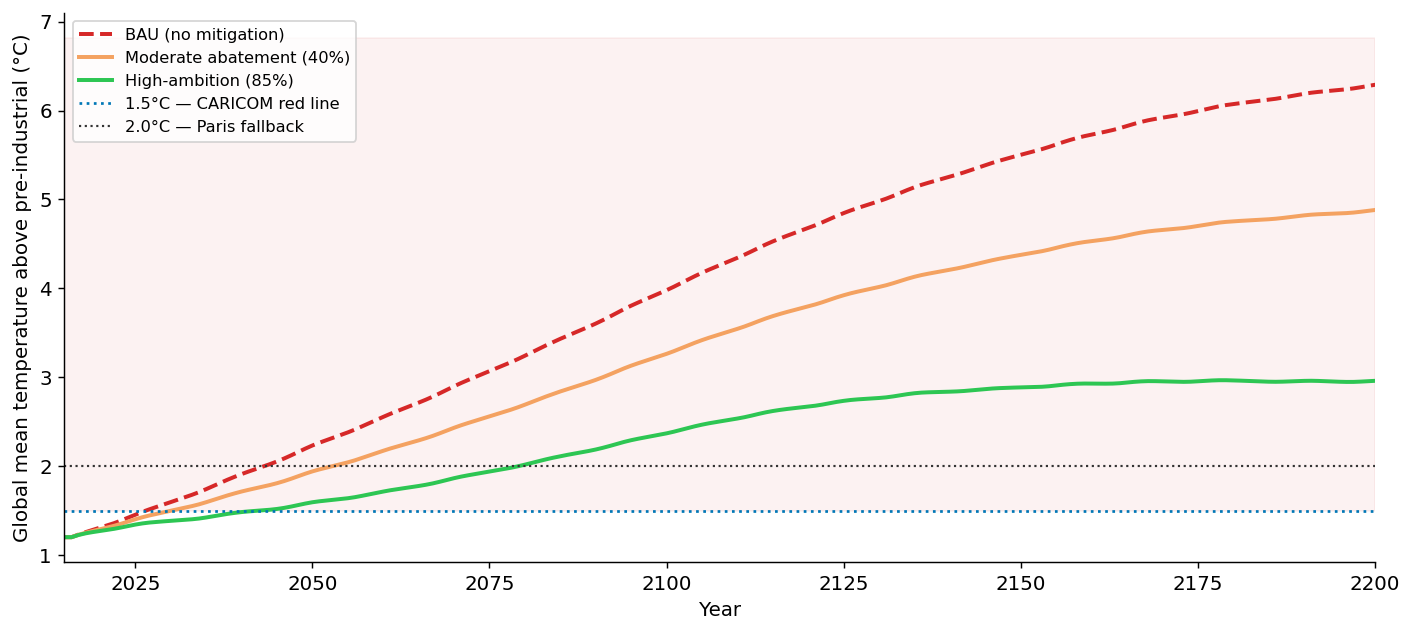

Saved: caricom_01_temperature.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

scenarios = {
    'BAU (no mitigation)':         (ds_bau, C_DANGER, '--'),
    'Moderate abatement (40%)':    (ds_mod, C_WARN,   '-'),
    'High-ambition (85%)':         (ds_hi,  C_SAFE,   '-'),
}

for label, (ds, color, ls) in scenarios.items():
    temp = np.squeeze(ds['global_temperature'])
    ax.plot(years, temp, color=color, linestyle=ls, linewidth=2.2, label=label)

# Paris Agreement thresholds
ax.axhline(1.5, color=C_CARIB,  linewidth=1.5, linestyle=':', label='1.5°C — CARICOM red line')
ax.axhline(2.0, color='#333333', linewidth=1.2, linestyle=':', label='2.0°C — Paris fallback')

# Shade danger zone
ax.axhspan(1.5, ax.get_ylim()[1] if ax.get_ylim()[1] > 1.5 else 6, 
           alpha=0.06, color=C_DANGER)

ax.set_xlim(2015, 2200)
ax.set_xlabel('Year')
ax.set_ylabel('Global mean temperature above pre-industrial (°C)')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_01_temperature.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_01_temperature.png')

---
## Part 3: Damage burden (who pays?)

**Key CARICOM argument:** The Caribbean bears a disproportionate share of climate damages despite contributing negligibly to cumulative emissions. This is the core injustice: the regions least responsible for the problem suffer the most from it.

The scatter plot maps each region's **share of cumulative emissions** (x-axis) against its **share of cumulative climate damages** (y-axis) over 2015-2100. Regions above the diagonal carry more damage than their emissions share justifies. Regions below it are net beneficiaries of others' emissions. The Caribbean sits firmly in the upper-left quadrant: high damage, near-zero emissions responsibility.


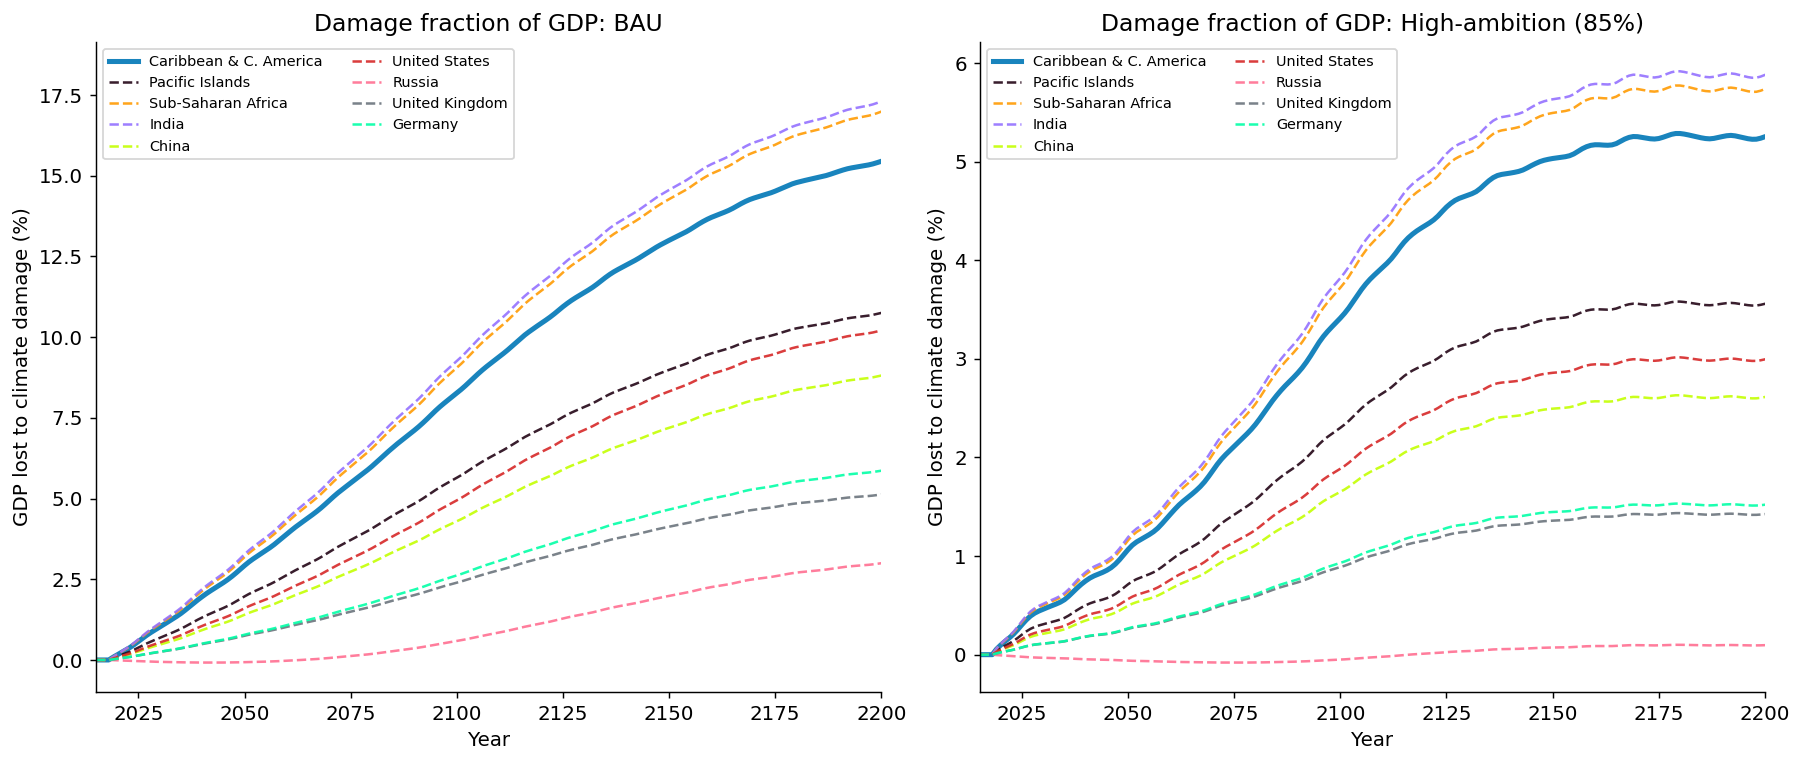

Saved: caricom_02_damage_fraction.png


In [ ]:
# Extract damage fraction time series for focus regions
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, (policy_label, ds) in zip(axes, [('BAU', ds_bau), ('High-ambition (85%)', ds_hi)]):
    damage_frac = np.squeeze(ds.get('damage_fraction', ds.get('economic_damage', None)))
    
    # damage_fraction shape: (regions, timesteps) or (1, regions, timesteps)
    if damage_frac is None:
        # fallback: compute from economic_damage / gross_economic_output
        damage_frac = (np.squeeze(ds['economic_damage']) /
                       np.squeeze(ds['gross_economic_output']))
    
    if damage_frac.ndim > 2:
        damage_frac = damage_frac[0]

    for code, name in FOCUS_REGIONS.items():
        try:
            idx = region_idx(code)
        except ValueError:
            continue
        series = damage_frac[idx] * 100  # convert to %
        color  = C_CARIB   if code == 'rcam'   else \
                 C_EXTRA2  if code == 'rfa' else \
                 C_EXTRA3  if code == 'rus' else \
                 C_EXTRA4  if code == 'nde' else \
                 C_DANGER  if code == 'usa' else \
                 C_EXTRA5  if code == 'chn' else \
                 C_EXTRA6  if code == 'rsaf' else \
                 C_EXTRA7  if code == 'rjan57' else \
                 C_NEUTRAL
        
        lw     = 2.8 if code == 'rcam' else 1.4
        ls     = '-' if code == 'rcam' else '--'
        ax.plot(years, series, color=color, linewidth=lw, linestyle=ls,
                label=name, alpha=0.9)

    ax.set_title(f'Damage fraction of GDP: {policy_label}')
    ax.set_xlabel('Year')
    ax.set_ylabel('GDP lost to climate damage (%)')
    ax.set_xlim(2015, 2200)
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_02_damage_fraction.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_02_damage_fraction.png')

---
## Part 4: Abatement burden vs damage burden

**Key CARICOM argument:** Small island developing states already suffer the highest damage burdens. Asking them to also bear equal abatement costs (as a flat ECR would imply) compounds the injustice. The principle of **Common But Differentiated Responsibilities and Respective Capabilities (CBDR-RC)** requires that historically high-emitting, high-income nations carry the bulk of abatement cost.

This chart compares each region's abatement cost as a share of GDP against its damage cost as a share of GDP at a 2100 snapshot under the high-ambition scenario. Regions with high damage and limited abatement capacity are the ones CARICOM argues must be shielded from uniform burden-sharing.


Burden comparison at 2100 high-ambition scenario:


,Abatement burden (% GDP),Damage burden (% GDP)
Region,,
Caribbean & C. America,4.758,3.414
Pacific Islands,4.835,2.301
Sub-Saharan Africa,2.453,3.722
India,1.868,3.820
China,2.300,1.650
United States,3.137,1.886
Russia,3.342,-0.050
United Kingdom,1.349,0.888
Germany,3.788,0.930


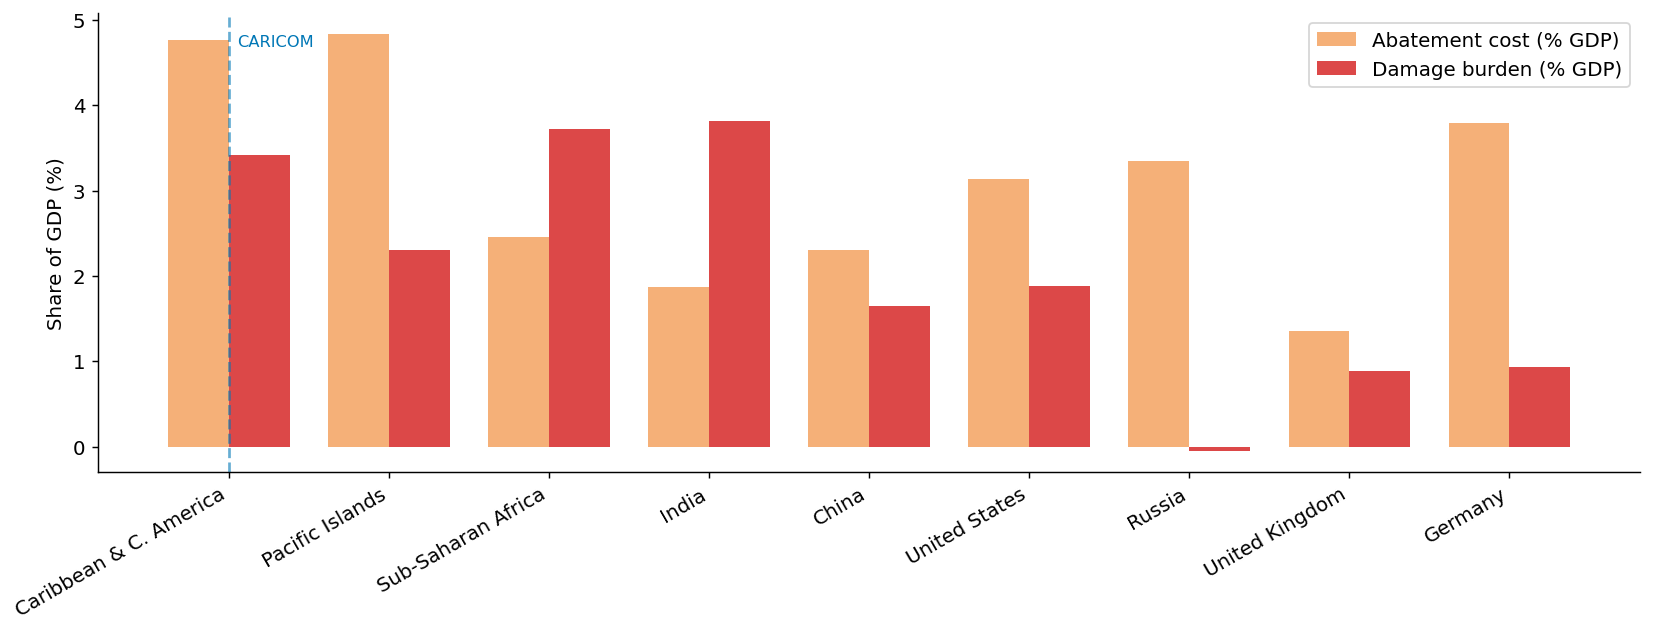

Saved: caricom_03_burden_comparison.png


In [ ]:
# Bar chart: 2100 snapshot -> abatement burden vs damage burden
year_snapshot = 2100
yr_idx = year_snapshot - 2015

records = []
for code, name in FOCUS_REGIONS.items():
    try:
        r_idx = region_idx(code)
    except ValueError:
        continue

    # Use HIGH-AMBITION scenario (abatement costs are real here)
    goe  = np.squeeze(ds_hi['gross_economic_output'])
    abt  = np.squeeze(ds_hi['abatement_cost'])
    dmg  = np.squeeze(ds_hi['economic_damage'])

    if goe.ndim > 2:  goe = goe[0]
    if abt.ndim > 2:  abt = abt[0]
    if dmg.ndim > 2:  dmg = dmg[0]

    abt_share = float(abt[r_idx, yr_idx] / goe[r_idx, yr_idx]) * 100
    dmg_share = float(dmg[r_idx, yr_idx] / goe[r_idx, yr_idx]) * 100
    records.append({'Region': name, 'code': code,
                    'Abatement burden (% GDP)': abt_share,
                    'Damage burden (% GDP)':    dmg_share})

df_burden = pd.DataFrame(records).set_index('Region').drop(columns='code')
print(f'Burden comparison at {year_snapshot} high-ambition scenario:')
display(df_burden.round(3))

# Plot
x = np.arange(len(df_burden))
w = 0.38
fig, ax = plt.subplots(figsize=(13, 5))

bars_abt = ax.bar(x - w/2, df_burden['Abatement burden (% GDP)'],
                  w, label='Abatement cost (% GDP)', color=C_WARN, alpha=0.85)
bars_dmg = ax.bar(x + w/2, df_burden['Damage burden (% GDP)'],
                  w, label='Damage burden (% GDP)', color=C_DANGER, alpha=0.85)

# Highlight CARICOM
carib_name = FOCUS_REGIONS.get('rcam', 'Caribbean & C. America')
if carib_name in df_burden.index:
    carib_x = list(df_burden.index).index(carib_name)
    ax.axvline(carib_x, color=C_CARIB, linewidth=1.5, linestyle='--', alpha=0.6)
    ax.text(carib_x + 0.05, ax.get_ylim()[1] * 0.95,
            'CARICOM', color=C_CARIB, fontsize=9, va='top')

ax.set_xticks(x)
ax.set_xticklabels(df_burden.index, rotation=30, ha='right')
ax.set_ylabel('Share of GDP (%)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_03_burden_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_03_burden_comparison.png')

Emissions responsibility vs damage share (2015-2100):
                          code  Emissions share (%)  Damage share (%)
Region                                                               
Caribbean & C. America    rcam                0.838             1.128
Pacific Islands         rjan57                0.330             0.235
Sub-Saharan Africa        rsaf                5.912            15.550
India                      nde               11.279            14.258
China                      chn               28.374             9.626
United States              usa               12.804             9.378
Russia                     rus                3.393            -0.107
United Kingdom             gbr                0.759             0.696
Germany                    rfa                1.382             0.682


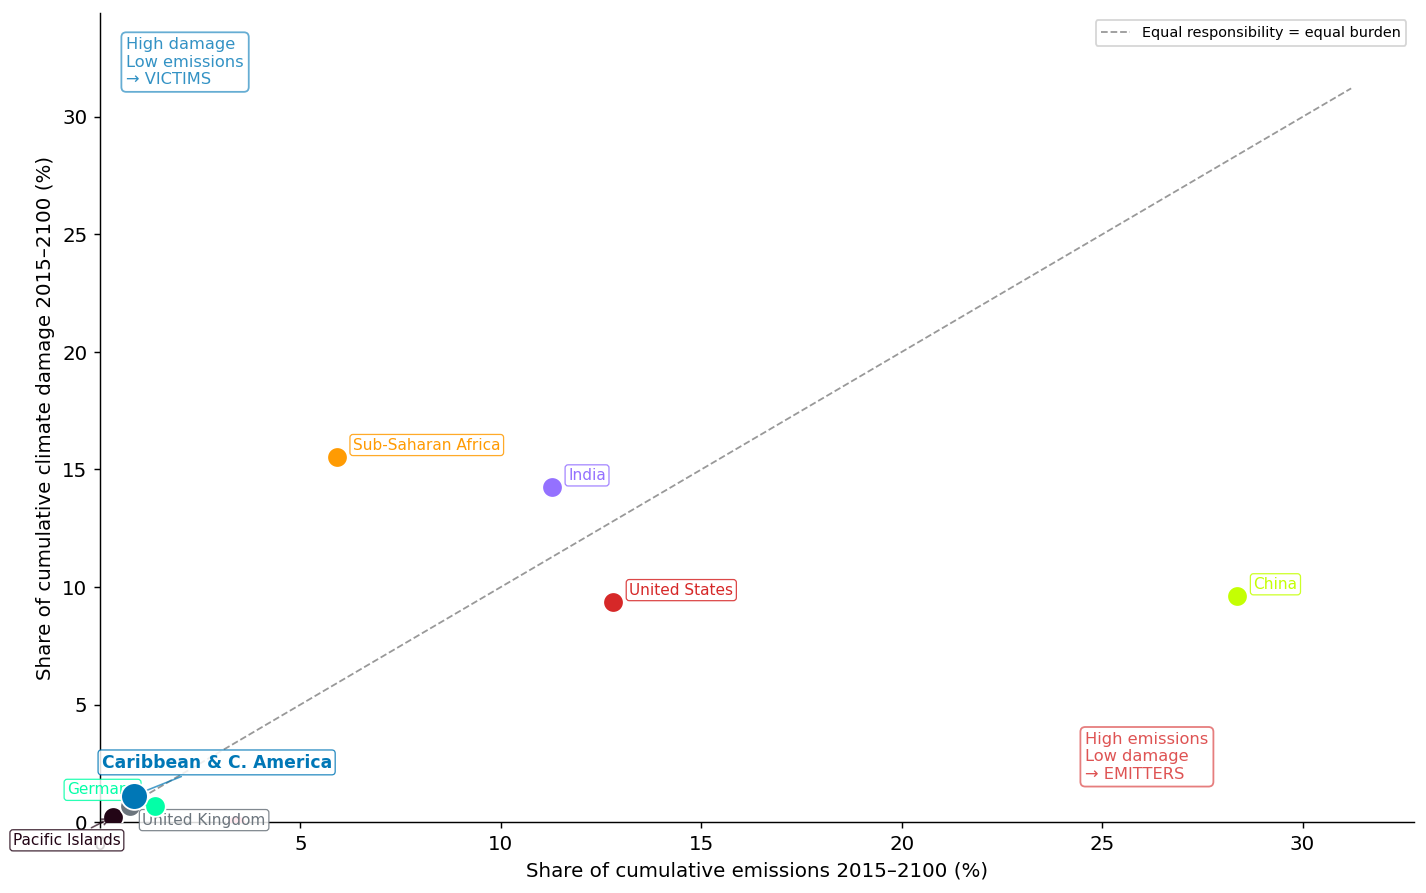

Saved: caricom_new_01_injustice_ratio.png


In [ ]:
year_start = 2015
year_end   = 2100
t0 = year_start - 2015
t1 = year_end   - 2015 + 1   # slice is exclusive
 
# Extract from BAU (emissions) and high-ambition (damages)
# Use BAU emissions -> reflects true responsibility (no abatement distortion)
# Use high-ambition damages -> still substantial but represents a plausible future
 
emis_raw = np.squeeze(ds_bau['emissions'])           # (regions, timesteps) or (1, r, t)
dmg_raw  = np.squeeze(ds_hi['economic_damage'])      # (regions, timesteps)
 
if emis_raw.ndim > 2: emis_raw = emis_raw[0]
if dmg_raw.ndim  > 2: dmg_raw  = dmg_raw[0]
 
# Cumulative sums 2015-2100 per region
cum_emis = emis_raw[:, t0:t1].sum(axis=1)   # shape (n_regions,)
cum_dmg  = dmg_raw[:, t0:t1].sum(axis=1)
 
# Global totals
total_emis = cum_emis.sum()
total_dmg  = cum_dmg.sum()
 
# Build records for focus regions
records_p1 = []
for code, name in FOCUS_REGIONS.items():
    try:
        r = region_idx(code)
    except ValueError:
        continue
    emis_share = float(cum_emis[r] / total_emis) * 100
    dmg_share  = float(cum_dmg[r]  / total_dmg)  * 100
    records_p1.append({
        'Region': name, 'code': code,
        'Emissions share (%)': emis_share,
        'Damage share (%)':    dmg_share,
    })
 
df_p1 = pd.DataFrame(records_p1)
print('Emissions responsibility vs damage share (2015-2100):')
print(df_p1.set_index('Region').round(3).to_string())

# Scatter plot
fig1, ax1 = plt.subplots(figsize=(11, 7))

# Per-region manual label offsets (x, y) in data units to avoid crowding.
# Negative x moves left, negative y moves down.
LABEL_OFFSETS = {
    'rcam':   (-0.8,  1.2),   # Caribbean: up and left
    'rjan57': (-2.5, -1.2),   # Pacific Islands: below and left
    'gbr':    ( 0.3, -0.8),   # UK: below
    'rus':    ( 0.3,  0.4),   # Russia: above
    'rfa':    (-2.2,  0.5),   # Germany: left
    'usa':    ( 0.4,  0.3),   # USA: above right
    'chn':    ( 0.4,  0.3),   # China: above right
    'nde':    ( 0.4,  0.3),   # India: above right
    'rsaf':   ( 0.4,  0.3),   # Sub-Saharan Africa: above right
}

for _, row in df_p1.iterrows():
    code   = row['code']
    is_car = code == 'rcam'
    color  = C_CARIB  if is_car else \
             C_DANGER if code == 'usa' else \
             C_EXTRA2 if code == 'rfa' else \
             C_EXTRA5 if code == 'chn' else \
             C_EXTRA3 if code == 'rus' else \
             C_EXTRA4 if code == 'nde' else \
             C_EXTRA6 if code == 'rsaf' else \
             C_EXTRA7 if code == 'rjan57' else \
             C_NEUTRAL

    ax1.scatter(row['Emissions share (%)'], row['Damage share (%)'],
                s=220 if is_car else 130,
                color=color,
                zorder=5 if is_car else 3,
                edgecolors='white', linewidths=1.0)

    x_off, y_off = LABEL_OFFSETS.get(code, (0.3, 0.3))
    x_txt = row['Emissions share (%)'] + x_off
    y_txt = row['Damage share (%)']    + y_off

    # Use arrowprops only when the label is far from the dot (offset > 1 unit away)
    use_arrow = abs(x_off) > 1.0 or abs(y_off) > 1.0
    arrow_kw = dict(
        arrowprops=dict(arrowstyle='->', color=color, lw=0.9, alpha=0.7)
    ) if use_arrow else {}

    ax1.annotate(
        row['Region'],
        xy=(row['Emissions share (%)'], row['Damage share (%)']),
        xytext=(x_txt, y_txt),
        fontsize=9.5 if is_car else 8.5,
        fontweight='bold' if is_car else 'normal',
        color=color,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color,
                  alpha=0.85, linewidth=0.7),
        **arrow_kw,
    )

# Diagonal line: equal responsibility = equal burden
lim_max = max(df_p1['Emissions share (%)'].max(), df_p1['Damage share (%)'].max()) * 1.1
ax1.plot([0, lim_max], [0, lim_max], 'k--', linewidth=1, alpha=0.4,
         label='Equal responsibility = equal burden')

# Shade the injustice quadrant (low emissions, high damage)
ax1.axhspan(df_p1['Damage share (%)'].mean(), ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 5,
            alpha=0.0)   # placeholder; we annotate instead

# Annotate the two quadrants
ax1.text(0.02, 0.97, 'High damage\nLow emissions\n→ VICTIMS',
         transform=ax1.transAxes, fontsize=9, va='top',
         color=C_CARIB, alpha=0.8,
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=C_CARIB, alpha=0.6))
ax1.text(0.75, 0.05, 'High emissions\nLow damage\n→ EMITTERS',
         transform=ax1.transAxes, fontsize=9, va='bottom',
         color=C_DANGER, alpha=0.8,
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=C_DANGER, alpha=0.6))

ax1.set_xlabel('Share of cumulative emissions 2015–2100 (%)', fontsize=11)
ax1.set_ylabel('Share of cumulative climate damage 2015–2100 (%)', fontsize=11)
ax1.legend(fontsize=8)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(f'{_PLOTS_DIR}/caricom_new_01_injustice_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_new_01_injustice_ratio.png')


---
## Part 5: Consumption per capita & the sufficiency floor

**SUFFICIENTARIAN argument:** The sufficiency floor is not met if Caribbean consumption per capita falls below the dynamic threshold (75% of the moderate-abatement, damage-free potential trajectory, see Part 0).

At the JUSTICE default damage scaling (δ = 1), the Caribbean does not breach the floor because the baseline damage function is calibrated on global averages and systematically underestimates small island exposure. When damage is scaled to δ = 1.5-2.0, which better reflects empirical evidence that SIDS face climate losses of **50–100% of annual GDP** from extreme events (Global Center on Adaptation, 2025), the Caribbean approaches and breaches the sufficiency floor under BAU.

This confirms two things: (1) the standard model parametrisation underestimates Caribbean climate risk; and (2) the SUFFICIENTARIAN welfare function remains the most appropriate normative choice for CARICOM, even though the δ = 1 run does not fully activate it.


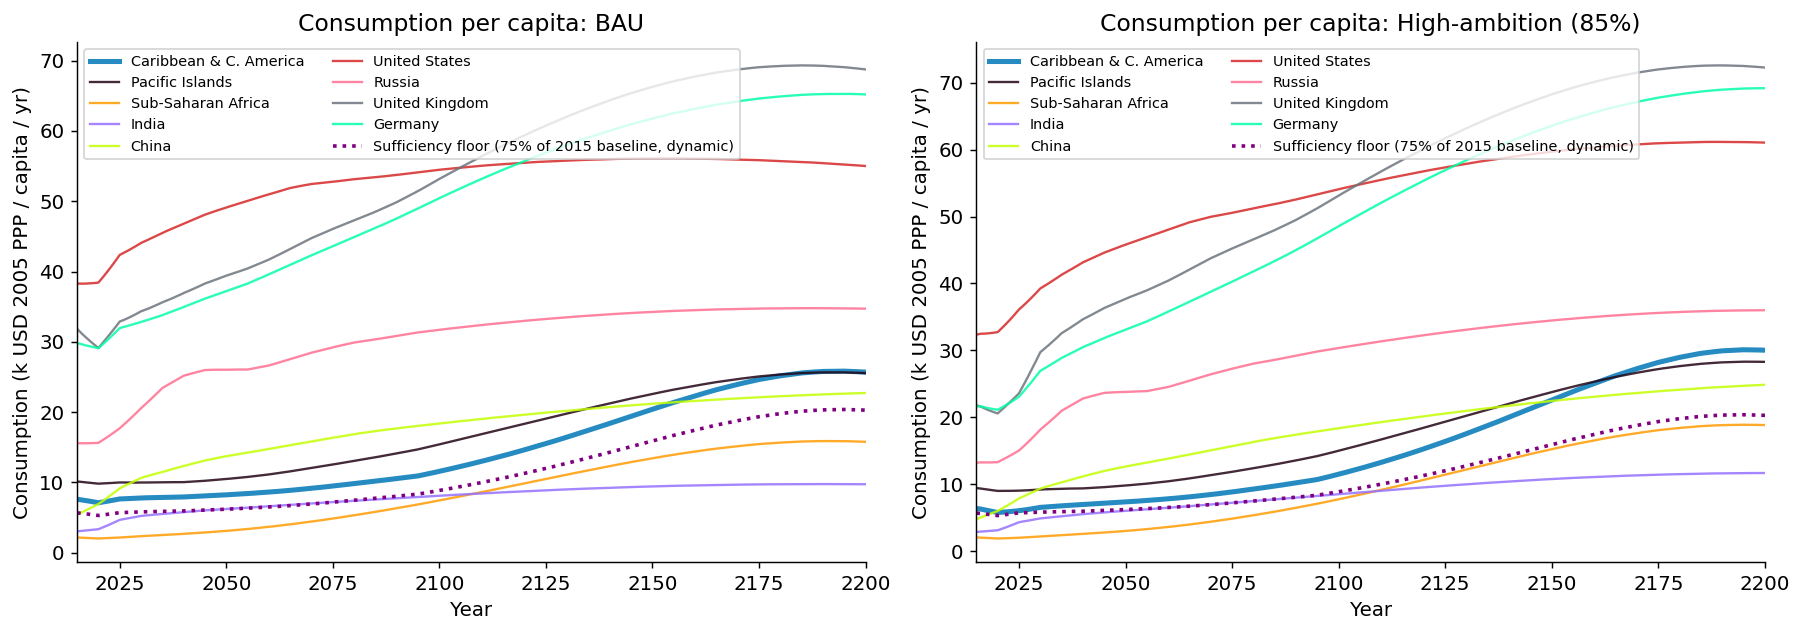

Saved: caricom_04_consumption_sufficiency.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sufficiency threshold from Cell 0
SUFFICIENCY_THRESHOLD = SUFFICIENCY_THR

for ax, (label, ds) in zip(axes, [('BAU', ds_bau), ('High-ambition (85%)', ds_hi)]):
    cpc = np.squeeze(ds['consumption_per_capita'])  # shape: (regions, timesteps)
    if cpc.ndim > 2: cpc = cpc[0]

    for code, name in FOCUS_REGIONS.items():
        try:
            r_idx = region_idx(code)
        except ValueError:
            continue
        series = cpc[r_idx]
        color  = C_CARIB   if code == 'rcam'   else \
                 C_EXTRA2  if code == 'rfa' else \
                 C_EXTRA3  if code == 'rus' else \
                 C_EXTRA4  if code == 'nde' else \
                 C_DANGER  if code == 'usa' else \
                 C_EXTRA5  if code == 'chn' else \
                 C_EXTRA6  if code == 'rsaf' else \
                 C_EXTRA7  if code == 'rjan57' else \
                 C_NEUTRAL
        lw     = 2.8 if code == 'rcam' else 1.3
        ax.plot(years, series, color=color, linewidth=lw,
                linestyle='-',
                label=name, alpha=0.85)

    ax.plot(years, SUFFICIENCY_THR_DYNAMIC, color='purple', linewidth=2, linestyle=':',
        label=f'Sufficiency floor (75% of 2015 baseline, dynamic)')
    ax.set_title(f'Consumption per capita: {label}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Consumption (k USD 2005 PPP / capita / yr)')
    ax.set_xlim(2015, 2200)
    ax.legend(fontsize=8, ncol=2, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_04_consumption_sufficiency.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_04_consumption_sufficiency.png')

---
### Part 5b: Caribbean CPC trajectory (BAU vs high-ambition)

This chart isolates the Caribbean region (`rcam`) across the three policy scenarios and plots the dynamic sufficiency floor for reference.

Key readings:
- The **gap between BAU and high-ambition at 2100** is the quantified benefit of global climate ambition to CARICOM. The consumption per capita that aggressive mitigation delivers for the Caribbean.
- Where the high-ambition line falls **below** BAU, abatement costs are temporarily biting into Caribbean consumption before the damage savings materialise.
- The sufficiency floor (dashed purple) shows how close BAU brings the Caribbean to the threshold under the baseline damage scaling.


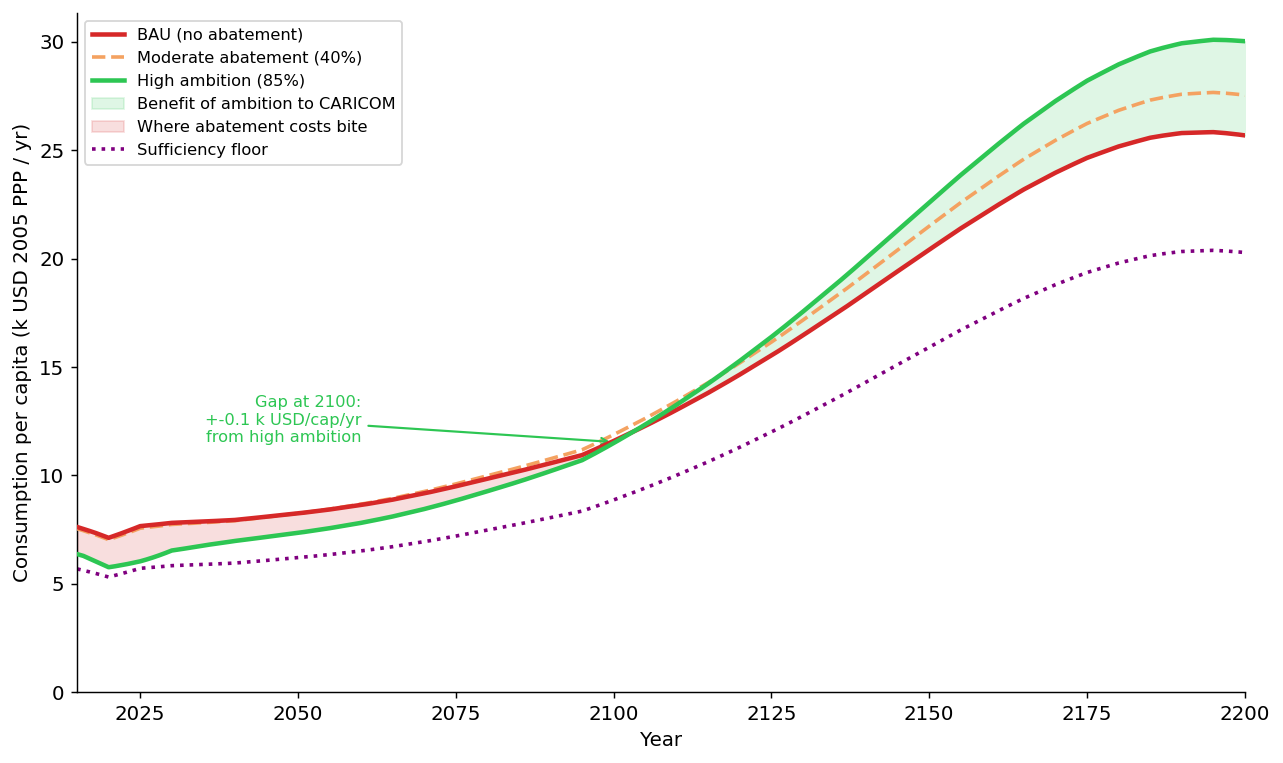

Saved: caricom_new_03_cpc_trajectory.png


In [ ]:
r_carib = region_idx('rcam')
 
cpc_bau = np.squeeze(ds_bau['consumption_per_capita'])
cpc_hi  = np.squeeze(ds_hi['consumption_per_capita'])
if cpc_bau.ndim > 2: cpc_bau = cpc_bau[0]
if cpc_hi.ndim  > 2: cpc_hi  = cpc_hi[0]
 
# Also pull moderate scenario if available
try:
    cpc_mod = np.squeeze(ds_mod['consumption_per_capita'])
    if cpc_mod.ndim > 2: cpc_mod = cpc_mod[0]
    HAS_MOD = True
except NameError:
    HAS_MOD = False
 
fig3, ax3 = plt.subplots(figsize=(10, 6))
 
ax3.plot(years, cpc_bau[r_carib], color=C_DANGER, linewidth=2.5,
         linestyle='-', label='BAU (no abatement)', zorder=4)
if HAS_MOD:
    ax3.plot(years, cpc_mod[r_carib], color=C_WARN, linewidth=2,
             linestyle='--', label='Moderate abatement (40%)', zorder=3)
ax3.plot(years, cpc_hi[r_carib], color=C_SAFE, linewidth=2.5,
         linestyle='-', label='High ambition (85%)', zorder=4)
 
# Shade the gap between BAU and high-ambition
ax3.fill_between(years,
                 cpc_bau[r_carib],
                 cpc_hi[r_carib],
                 where=(cpc_hi[r_carib] >= cpc_bau[r_carib]),
                 alpha=0.15, color=C_SAFE,
                 label='Benefit of ambition to CARICOM')
ax3.fill_between(years,
                 cpc_bau[r_carib],
                 cpc_hi[r_carib],
                 where=(cpc_hi[r_carib] < cpc_bau[r_carib]),
                 alpha=0.15, color=C_DANGER,
                 label='Where abatement costs bite')
 
# Reference lines
ax3.plot(years, SUFFICIENCY_THR_DYNAMIC, color='purple', linewidth=2, linestyle=':',
        label=f'Sufficiency floor')
 
# Annotate the gap at 2100
gap_2100 = float(cpc_hi[r_carib, 2100-2015] - cpc_bau[r_carib, 2100-2015])
ax3.annotate(f'Gap at 2100:\n+{gap_2100:.1f} k USD/cap/yr\nfrom high ambition',
             xy=(2100, (cpc_hi[r_carib, 2100-2015] + cpc_bau[r_carib, 2100-2015]) / 2),
             xytext=(2060, (cpc_hi[r_carib, 2100-2015] + cpc_bau[r_carib, 2100-2015]) / 2),
             fontsize=9, color=C_SAFE, ha='right',
             arrowprops=dict(arrowstyle='->', color=C_SAFE, lw=1.2))
 
ax3.set_xlim(2015, 2200)
ax3.set_ylim(bottom=0)
ax3.set_xlabel('Year')
ax3.set_ylabel('Consumption per capita (k USD 2005 PPP / yr)')
ax3.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig(f'{_PLOTS_DIR}/caricom_new_03_cpc_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_new_03_cpc_trajectory.png')

---
## Part 6: Scenario ensemble

This cell generates an ensemble of model runs across four uncertain dimensions:

| Dimension | Values explored | Rationale |
|---|---|---|
| SSP scenario | 1, 2, 3, 7 (SSP1-2.6 to SSP5-8.5) | Covers the range of plausible emission baselines |
| ECS ensemble member | 6 states (1-1001) | Captures climate sensitivity uncertainty |
| Damage scaling δ | 1.0, 2.0, 3.0, 4.0 | Reflects uncertainty in Caribbean-specific damage exposure |
| Emission control rate (ECR) | 0.0-0.9 in 6 steps | The key policy lever CARICOM is negotiating over |

**Output:** `df_ensemble` -> one row per run, recording Caribbean CPC at 2100, temperature at 2100, and whether each run meets the sufficiency threshold and the 1.5°C criterion. This dataframe feeds the sensitivity analysis, scenario discovery, and robustness cells.


In [ ]:
# Generate a scenario ensemble across all five uncertain dimensions:
#       SSP scenario, ECS ensemble member, damage scaling δ, ECR policy lever
# Output: df_ensemble -> one row per run, with Caribbean welfare outcome as target variable.
# This dataframe feeds the sensitivity analysis, scenario discovery, and robustness cells.

import itertools

SSP_ENSEMBLE   = [1, 2, 3, 7]           # SSP1-2.6, SSP2-4.5, SSP3-7.0, SSP5-8.5
ECS_ENSEMBLE   = [1, 200, 400, 600, 800, 1001]  # 6 states of the ECS world
DELTA_ENSEMBLE = [1.0, 2.0, 3.0, 4.0]   # damage scaling
ECR_ENSEMBLE   = np.linspace(0.0, 0.9, 6)  # policy lever 

N_TOTAL = len(SSP_ENSEMBLE) * len(ECS_ENSEMBLE) * len(DELTA_ENSEMBLE) * len(ECR_ENSEMBLE)
print(f'Ensemble: {N_TOTAL} runs')
print(f'  SSP × ECS × δ × ECR = '
      f'{len(SSP_ENSEMBLE)} × {len(ECS_ENSEMBLE)} × {len(DELTA_ENSEMBLE)} × {len(ECR_ENSEMBLE)}')

ens_records = []
r_carib = region_idx('rcam')

for i, (ssp, ecs, delta, ecr) in enumerate(
        itertools.product(SSP_ENSEMBLE, ECS_ENSEMBLE, DELTA_ENSEMBLE, ECR_ENSEMBLE)):
    try:
        JUSTICE.hard_reset()
        model = JUSTICE(
            start_year=2015, end_year=2300, timestep=1,
            scenario=ssp,
            climate_ensembles=int(np.clip(ecs, 1, 1001)),
            stochastic_run=False,
            social_welfare_function=WelfareFunction.SUFFICIENTARIAN,
        )
        # Apply damage scaling
        model.damage_function.coefficient_a                  *= float(delta)
        model.damage_function.coefficient_b                  *= float(delta)
        model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

        ecr_arr = np.full(model.emission_control_rate.shape[:2], float(ecr))
        model.run(emission_control_rate=ecr_arr, endogenous_savings_rate=True)
        ds = model.evaluate()

        cpc = np.squeeze(ds['consumption_per_capita'])
        if cpc.ndim > 2: cpc = cpc[0]
        carib_cpc_2100 = float(cpc[r_carib, 2100 - 2015])

        temp = np.squeeze(ds['global_temperature'])
        temp_2100 = float(temp[2100 - 2015])

        dmg = np.squeeze(ds['economic_damage'])
        goe = np.squeeze(ds['gross_economic_output'])
        if dmg.ndim > 2: dmg = dmg[0]
        if goe.ndim > 2: goe = goe[0]
        carib_dmg_frac_2100 = float(dmg[r_carib, 2100 - 2015] /
                                     goe[r_carib, 2100 - 2015]) * 100

        ens_records.append({
            'ssp': ssp, 'ecs': ecs, 'delta': delta, 'ecr': ecr,
            'carib_cpc_2100':      carib_cpc_2100,
            'temp_2100':           temp_2100,
            'carib_dmg_frac_2100': carib_dmg_frac_2100,
            'meets_sufficiency': bool(np.all(cpc[r_carib, :] >= SUFFICIENCY_THR_DYNAMIC)),
            'meets_1p5C':          temp_2100 <= 1.5,
        })
    except Exception as e:
        print(f'  Run {i+1}/{N_TOTAL} failed (SSP={ssp}, ECS={ecs}, δ={delta}, ECR={ecr:.2f}): {e}')
        continue

    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{N_TOTAL} runs complete ...')

df_ensemble = pd.DataFrame(ens_records)
print(f'\n✓ Ensemble complete: {len(df_ensemble)} successful runs')
print(f'  Fraction meeting sufficiency threshold: {df_ensemble["meets_sufficiency"].mean():.1%}')
print(f'  Fraction meeting 1.5°C criterion:       {df_ensemble["meets_1p5C"].mean():.1%}')
display(df_ensemble.describe().round(3))


Ensemble: 576 runs
  SSP × ECS × δ × ECR = 4 × 6 × 4 × 6
  20/576 runs complete ...
  40/576 runs complete ...
  60/576 runs complete ...
  80/576 runs complete ...
  100/576 runs complete ...
  120/576 runs complete ...
  140/576 runs complete ...
  160/576 runs complete ...
  180/576 runs complete ...
  200/576 runs complete ...
  220/576 runs complete ...
  240/576 runs complete ...
  260/576 runs complete ...
  280/576 runs complete ...
  300/576 runs complete ...
  320/576 runs complete ...
  340/576 runs complete ...
  360/576 runs complete ...
  380/576 runs complete ...
  400/576 runs complete ...
  420/576 runs complete ...
  440/576 runs complete ...
  460/576 runs complete ...
  480/576 runs complete ...
  500/576 runs complete ...
  520/576 runs complete ...
  540/576 runs complete ...
  560/576 runs complete ...

✓ Ensemble complete: 576 successful runs
  Fraction meeting sufficiency threshold: 83.7%
  Fraction meeting 1.5°C criterion:       12.5%


,ssp,ecs,delta,ecr,carib_cpc_2100,temp_2100,carib_dmg_frac_2100
count,576.00,576.000,576.000,576.000,576.000,576.000,576.000
mean,3.25,500.333,2.500,0.450,36.664,2.535,10.221
std,2.28,341.862,1.119,0.308,19.413,0.951,8.139
min,1.00,1.000,1.000,0.000,7.236,0.922,-4.219
25%,1.75,200.000,1.750,0.180,17.775,1.848,4.217
50%,2.50,500.000,2.500,0.450,33.956,2.377,8.321
75%,4.00,800.000,3.250,0.720,46.769,3.031,14.581
max,7.00,1001.000,4.000,0.900,74.483,6.082,47.345


---
## Part 7: Sensitivity analysis

**Question:** Which of the four uncertain input dimensions most strongly drives variation in CARICOM's welfare outcome (Caribbean CPC at 2100)?

**Method:** Standardised linear regression coefficients across the ensemble. Each coefficient gives the change in Caribbean CPC at 2100 per one standard-deviation change in the input, holding others constant. The absolute value is plotted -> a larger bar means stronger influence.

**Why this matters:** Sensitivity analysis tells us where uncertainty resolution has the highest value and which variables CARICOM should focus its negotiating arguments on. If ECR dominates, policy action is decisive. If δ dominates, the scientific case for Caribbean-calibrated damage functions is more important.


Standardised linear regression: sensitivity of Caribbean CPC at 2100
ssp      10.4492
delta     2.5246
ecr       1.3905
ecs       1.1484

R² = 0.316


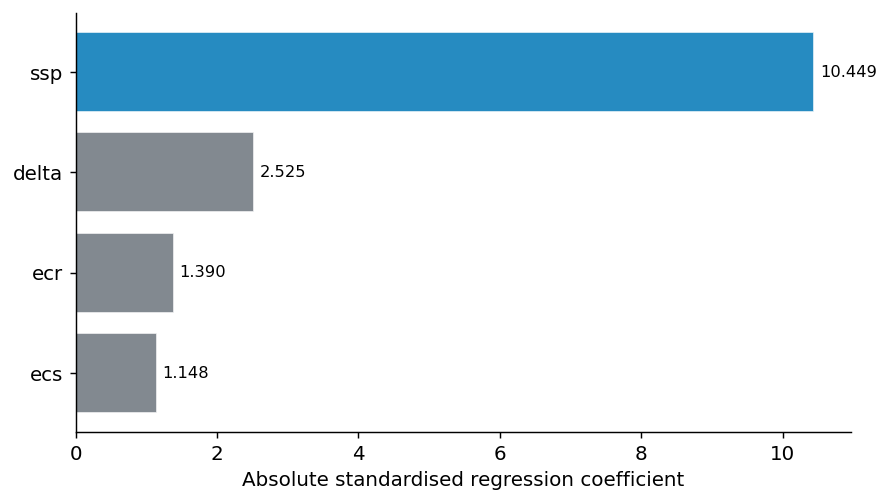


Interpretation:
  ssp   : Socioeconomic pathway (global development trajectory)
  delta : Damage scaling δ (how bad SIDS climate damages really are)
  ecr   : Emission Control Rate (the lever CARICOM advocates for)
  ecs   : Equilibrium Climate Sensitivity (physical uncertainty)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X_cols = ['ssp', 'ecs', 'delta', 'ecr']
y_col  = 'carib_cpc_2100'

X = df_ensemble[X_cols].values
y = df_ensemble[y_col].values

scaler = StandardScaler()
X_std  = scaler.fit_transform(X)

reg = LinearRegression().fit(X_std, y)
sensitivity = pd.Series(np.abs(reg.coef_), index=X_cols).sort_values(ascending=False)

print('Standardised linear regression: sensitivity of Caribbean CPC at 2100')
print(sensitivity.round(4).to_string())
print(f'\nR² = {reg.score(X_std, y):.3f}')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
colors_sa = [C_CARIB if v == sensitivity.max() else C_NEUTRAL for v in sensitivity.values]
bars = ax.barh(sensitivity.index[::-1], sensitivity.values[::-1],
               color=colors_sa[::-1], alpha=0.85, edgecolor='white')
ax.set_xlabel('Absolute standardised regression coefficient')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_SA_sensitivity.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Label what each input means for the report
labels = {
    'ecr':   'Emission Control Rate (the lever CARICOM advocates for)',
    'delta': 'Damage scaling δ (how bad SIDS climate damages really are)',
    'ssp':   'Socioeconomic pathway (global development trajectory)',
    'ecs':   'Equilibrium Climate Sensitivity (physical uncertainty)',
}
print('\nInterpretation:')
for var in sensitivity.index:
    print(f'  {var:6s}: {labels[var]}')

---
## Part 8: Scenario discovery

**Question:** Under exactly which combinations of conditions does CARICOM fall below the sufficiency threshold?

**Method:** PRIM (Patient Rule Induction Method) from `ema_workbench`. PRIM searches the input space for a "box" (a set of ranges on the input dimensions) that concentrates the failure cases (runs where Caribbean CPC falls below the floor). The output is an interpretable rule of the form:

*CARICOM is at risk WHEN ECR < X AND δ < Y AND SSP ≥ Z*

**Why this matters:** Scenario discovery translates the ensemble into a concrete negotiating condition. It lets CARICOM say: "Unless emission control reaches at least X and damage compensation accounts for at least Y, our sufficiency floor is not met in the majority of plausible futures."


Scenario discovery: conditions under which CARICOM falls below sufficiency threshold
Failure rate in ensemble: 16.3%

coverage     0.244681
density      0.638889
id           6.000000
k           23.000000
mass         0.062500
mean         0.638889
n           36.000000
res_dim      2.000000
Name: 6, dtype: float64

      box 6                         
        min  max  qp value  qp value
ssp     3.0  3.0  0.000004  0.002097
delta   3.5  4.0  0.003582       NaN

[None]


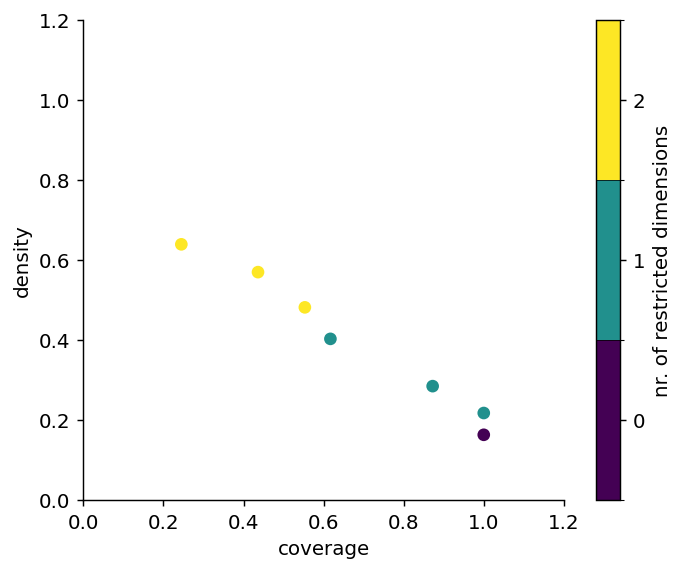

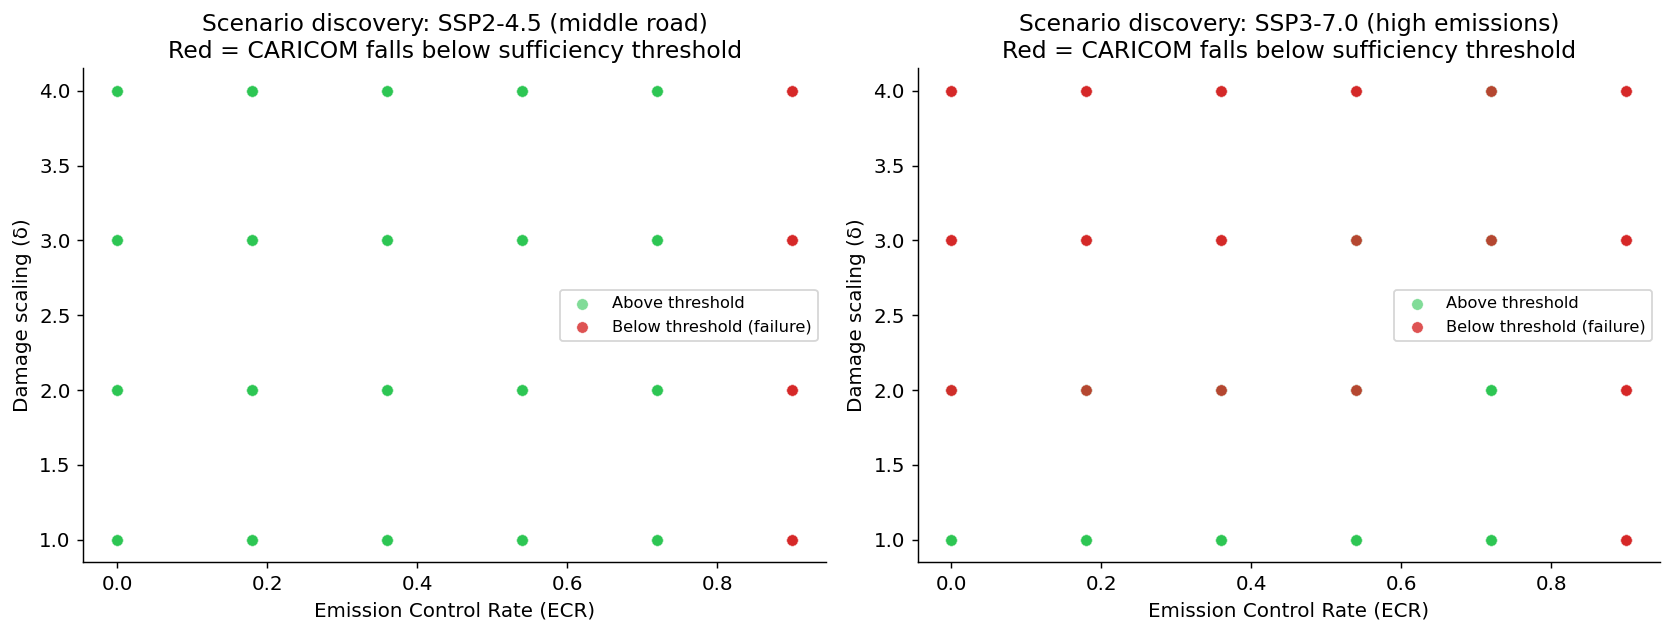

Saved: caricom_SD_scenario_discovery.png


In [ ]:
from ema_workbench.analysis import prim

X_sd = df_ensemble[['ssp', 'ecs', 'delta', 'ecr']]
y_sd = (~df_ensemble['meets_sufficiency']).astype(float).values  # 1 = failure

print('Scenario discovery: conditions under which CARICOM falls below sufficiency threshold')
print(f'Failure rate in ensemble: {y_sd.mean():.1%}\n')

prim_alg = prim.Prim(X_sd, y_sd, peel_alpha=0.05, paste_alpha=0.05, mass_min=0.05)
box = prim_alg.find_box()
box.show_tradeoff()
print(box.inspect(style='table'))

# Plot: scatter of failure/success in ECR vs delta space (most policy-relevant 2D slice)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ssp_val, ssp_name in zip(axes, [2, 3], ['SSP2-4.5 (middle road)', 'SSP3-7.0 (high emissions)']):
    sub = df_ensemble[df_ensemble['ssp'] == ssp_val]
    fail = sub[~sub['meets_sufficiency']]
    succ = sub[sub['meets_sufficiency']]
    ax.scatter(succ['ecr'], succ['delta'], color=C_SAFE,   alpha=0.6, s=40,
               label='Above threshold', edgecolors='white', linewidths=0.3)
    ax.scatter(fail['ecr'], fail['delta'], color=C_DANGER, alpha=0.8, s=40,
               label='Below threshold (failure)', edgecolors='white', linewidths=0.3)
    ax.set_xlabel('Emission Control Rate (ECR)')
    ax.set_ylabel('Damage scaling (δ)')
    ax.set_title(f'Scenario discovery: {ssp_name}\n'
                 'Red = CARICOM falls below sufficiency threshold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_SD_scenario_discovery.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_SD_scenario_discovery.png')

---
## Part 9: Robustness

**Question:** Which ECR levels keep CARICOM above the sufficiency threshold across the widest range of plausible futures?

This analysis reuses the ensemble from Part 6, so no new model runs are needed. For each ECR level it computes, across all SSP × ECS × δ combinations:
- The **fraction of scenarios where CARICOM meets the sufficiency threshold** (sufficiency robustness)
- The **fraction of scenarios where global temperature stays ≤ 1.5°C at 2100** (temperature robustness)

A robustness score of 0.5 means the criterion is met in half of all plausible futures. CARICOM's satisficing target is to find the minimum ECR that achieves ≥ 50% sufficiency robustness. This is the lowest policy ambition that keeps the Caribbean above the floor more often than not across the uncertainty space.


In [4]:
rob_by_ecr = (
    df_ensemble
    .groupby('ecr')
    .agg(
        sufficiency_robustness=('meets_sufficiency', 'mean'),
        temp_robustness       =('meets_1p5C',        'mean'),
        n_scenarios           =('meets_sufficiency', 'count'),
    )
    .reset_index()
)

print('Robustness by ECR level (fraction of scenarios meeting each criterion):')
display(rob_by_ecr.round(3))

# Find the minimum ECR that achieves ≥50% sufficiency robustness
robust_ecr = rob_by_ecr[rob_by_ecr['sufficiency_robustness'] >= 0.5]['ecr']
min_robust_ecr = float(robust_ecr.min()) if len(robust_ecr) > 0 else float('nan')
print(f'\nMinimum ECR for ≥50% sufficiency robustness: {min_robust_ecr:.2f}')

# Also break down robustness by SSP to show which futures are most dangerous
rob_by_ecr_ssp = (
    df_ensemble
    .groupby(['ecr', 'ssp'])['meets_sufficiency']
    .mean()
    .unstack('ssp')
    .rename(columns={1: 'SSP1-2.6', 2: 'SSP2-4.5', 3: 'SSP3-7.0', 7: 'SSP5-8.5'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: robustness curves by SSP
ax1 = axes[0]
ssp_colors = {'SSP1-2.6': C_SAFE, 'SSP2-4.5': C_WARN, 'SSP3-7.0': C_DANGER, 'SSP5-8.5': C_EXTRA}
for col in rob_by_ecr_ssp.columns:
    ax1.plot(rob_by_ecr_ssp.index, rob_by_ecr_ssp[col],
             color=ssp_colors.get(col, C_NEUTRAL), linewidth=2, marker='o',
             markersize=5, label=col)
ax1.axhline(0.5, color='black', linewidth=1.2, linestyle='--', label='50% robustness threshold')
if not np.isnan(min_robust_ecr):
    ax1.axvline(min_robust_ecr, color=C_CARIB, linewidth=1.5, linestyle=':',
                label=f'Min robust ECR = {min_robust_ecr:.2f}')
ax1.set_xlabel('Emission Control Rate (ECR)')
ax1.set_ylabel('Fraction of scenarios meeting sufficiency threshold')
ax1.set_title('Robustness: sufficiency threshold by SSP scenario\n')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.05)

# Right: dual-criterion view -> sufficiency AND 1.5°C
ax2 = axes[1]
ax2.plot(rob_by_ecr['ecr'], rob_by_ecr['sufficiency_robustness'],
         color=C_CARIB, linewidth=2.2, marker='o', markersize=5,
         label='Sufficiency robustness (CPC ≥ threshold)')
ax2.plot(rob_by_ecr['ecr'], rob_by_ecr['temp_robustness'],
         color=C_DANGER, linewidth=2.2, marker='s', markersize=5,
         label='Temperature robustness (T ≤ 1.5°C)')
ax2.axhline(0.5, color='black', linewidth=1.2, linestyle='--')
ax2.set_xlabel('Emission Control Rate (ECR)')
ax2.set_ylabel('Fraction of ensemble scenarios satisfied')
ax2.set_title('Dual-criterion robustness\n'
              'CARICOM needs both: sufficiency floor AND 1.5°C limit')
ax2.legend(fontsize=9)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_ROB_robustness.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_ROB_robustness.png')
print(f'\nKey finding: ECR ≥ {min_robust_ecr:.2f} needed for ≥50% sufficiency robustness')

NameError: name 'df_ensemble' is not defined

---
## Part 10: Rival welfare function framing

**Question:** What does CARICOM sacrifice if the negotiation adopts a UTILITARIAN welfare function instead of SUFFICIENTARIAN?

This cell runs all four welfare functions (UTILITARIAN, PRIORITARIAN, EGALITARIAN, SUFFICIENTARIAN), each optimised to its own best ECR, and compares the resulting Caribbean CPC at 2100. The comparison shows:
- How much each welfare function "sees" the Caribbean in its optimisation
- What ECR each function recommends and therefore how much global mitigation effort each implies
- Whether any welfare function other than SUFFICIENTARIAN keeps the Caribbean above the sufficiency floor

This is the model-based rebuttal to delegations that argue a utilitarian framing is sufficient.


In [ ]:
from itertools import product

WF_OPTIONS = {
    'UTILITARIAN':     WelfareFunction.UTILITARIAN,
    'PRIORITARIAN':    WelfareFunction.PRIORITARIAN,
    'EGALITARIAN':     WelfareFunction.EGALITARIAN,
    'SUFFICIENTARIAN': WelfareFunction.SUFFICIENTARIAN,
}

ECR_GRID = np.linspace(0.0, 0.95, 10)

# find optimal ECR for each welfare function
optimal_ecr = {}
for wf_name, wf_enum in WF_OPTIONS.items():
    print(f'Optimising ECR for {wf_name} ...')
    best_ecr, best_wf = 0.0, -np.inf
    for ecr_v in ECR_GRID:
        JUSTICE.hard_reset()
        m = JUSTICE(start_year=2015, end_year=2300, timestep=1,
                    scenario=2, climate_ensembles=1, stochastic_run=False,
                    social_welfare_function=wf_enum)
        m.run(emission_control_rate=np.full(m.emission_control_rate.shape[:2], ecr_v),
              endogenous_savings_rate=True)
        wf_val = float(np.squeeze(m.evaluate()['welfare']))
        if wf_val > best_wf:
            best_wf  = wf_val
            best_ecr = ecr_v
    optimal_ecr[wf_name] = best_ecr
    print(f'  → optimal ECR = {best_ecr:.2f}  (welfare = {best_wf:.4f})')

print('\nOptimal ECRs:', optimal_ecr)

# re-run at each optimal ECR and compare Caribbean CPC
comparison = {}
for wf_name, wf_enum in WF_OPTIONS.items():
    _, ds = run_justice(ecr_value=optimal_ecr[wf_name], welfare_fn=wf_enum)
    for code, name in FOCUS_REGIONS.items():
        try:
            r_idx = region_idx(code)
            cpc   = np.squeeze(ds['consumption_per_capita'])
            if cpc.ndim > 2: cpc = cpc[0]
            comparison.setdefault(name, {})[wf_name] = round(
                float(cpc[r_idx, 2100-2015]), 4)
        except Exception:
            pass

df_rival = pd.DataFrame(comparison).T
print('\nConsumption per capita at 2100, each run at its own optimal ECR:')
display(df_rival)
print('\nOptimal ECR chosen by each welfare function:')
for wf_name, ecr in optimal_ecr.items():
    print(f'  {wf_name}: {ecr:.2f}')

Optimising ECR for UTILITARIAN ...
  → optimal ECR = 0.42  (welfare = -103.5844)
Optimising ECR for PRIORITARIAN ...
  → optimal ECR = 0.74  (welfare = -411.9901)
Optimising ECR for EGALITARIAN ...
  → optimal ECR = 0.63  (welfare = -430.4244)
Optimising ECR for SUFFICIENTARIAN ...
  → optimal ECR = 0.32  (welfare = -110.3616)

Optimal ECRs: {'UTILITARIAN': np.float64(0.4222222222222222), 'PRIORITARIAN': np.float64(0.7388888888888889), 'EGALITARIAN': np.float64(0.6333333333333333), 'SUFFICIENTARIAN': np.float64(0.31666666666666665)}

Consumption per capita at 2100 — each run at its own optimal ECR:


,UTILITARIAN,PRIORITARIAN,EGALITARIAN,SUFFICIENTARIAN
Caribbean & C. America,11.8877,11.6101,11.7261,11.8315
Pacific Islands,15.6791,15.2056,15.3973,15.6377
Sub-Saharan Africa,7.7084,7.6906,7.6887,7.6480
India,8.4037,8.4040,8.3823,8.3355
China,18.6737,18.2570,18.3476,18.6182
United States,55.3207,54.1624,54.5201,55.1769
Russia,31.7247,30.5894,30.9608,31.7672
United Kingdom,53.5407,52.7360,52.8532,53.4845
Germany,50.7424,48.9974,49.5944,50.7438



Optimal ECR chosen by each welfare function:
  UTILITARIAN: 0.42
  PRIORITARIAN: 0.74
  EGALITARIAN: 0.63
  SUFFICIENTARIAN: 0.32


Using existing df_rival from notebook.


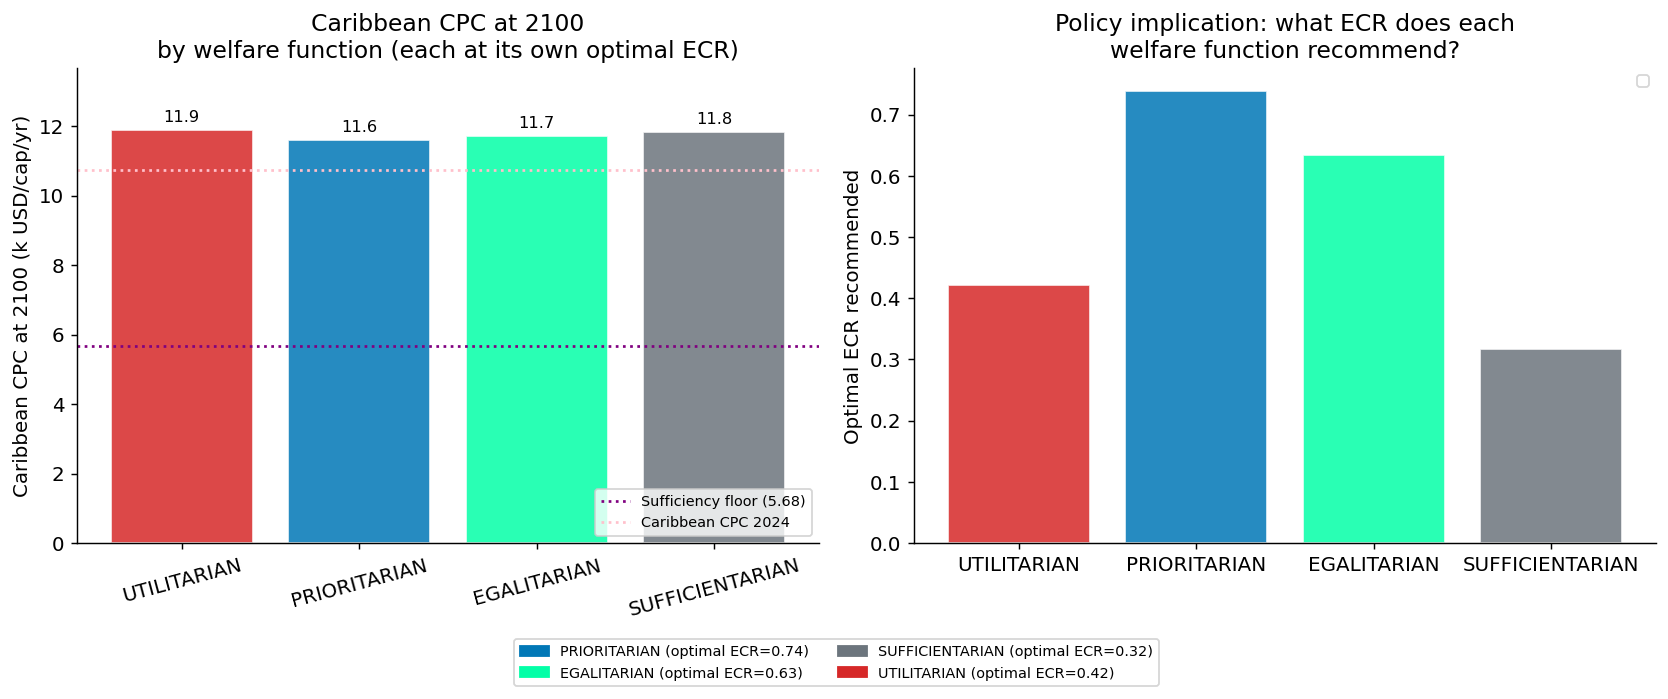

Saved: caricom_new_05_swf_regional_welfare.png


In [ ]:
# Regional welfare contribution: how much does each SWF "see" the Caribbean?

# The comparison table already computed in Part 9 is used
# (df_rival: CPC at 2100 by region × welfare function, each at its own optimal ECR).

# Here re-expressed as a heatmap-style bar chart:
# For each welfare function, Caribbean CPC at 2100 vs global max CPC at 2100 plotted.
# -> Shows how much each SWF "lifts" the Caribbean vs how much it gives to rich regions.

# If df_rival is not in scope, rebuild it from WF_OPTIONS and optimal_ecr.
 
try:
    _ = df_rival
    print('Using existing df_rival.')
except NameError:
    print('df_rival not found — re-running welfare comparison...')
    comparison = {}
    for wf_name, wf_enum in WF_OPTIONS.items():
        _, ds = run_justice(ecr_value=optimal_ecr[wf_name], welfare_fn=wf_enum)
        for code, name in FOCUS_REGIONS.items():
            try:
                r_idx = region_idx(code)
                cpc   = np.squeeze(ds['consumption_per_capita'])
                if cpc.ndim > 2: cpc = cpc[0]
                comparison.setdefault(name, {})[wf_name] = round(
                    float(cpc[r_idx, 2100-2015]), 4)
            except Exception:
                pass
    df_rival = pd.DataFrame(comparison).T
 
# Panel A: Caribbean CPC by SWF 
wf_labels  = list(df_rival.columns)
carib_name = FOCUS_REGIONS['rcam']
carib_vals = [df_rival.loc[carib_name, wf] for wf in wf_labels]
 
# Colour bars 
wf_colors = []
for wf in wf_labels:
    if wf == 'PRIORITARIAN':
        wf_colors.append(C_CARIB)
    elif wf == 'UTILITARIAN':
        wf_colors.append(C_DANGER)
    elif wf == 'EGALITARIAN':
        wf_colors.append(C_EXTRA2)
    else:
        wf_colors.append(C_NEUTRAL)
 
fig5, axes5 = plt.subplots(1, 2, figsize=(13, 5))
 
# Left panel: Caribbean CPC at 2100 under each SWF at that SWF's optimal ECR
ax5a = axes5[0]
bars = ax5a.bar(wf_labels, carib_vals, color=wf_colors, alpha=0.85, edgecolor='white')
ax5a.axhline(SUFFICIENCY_THR, color='purple', linewidth=1.5, linestyle=':',
             label=f'Sufficiency floor ({SUFFICIENCY_THR:.2f})')
ax5a.axhline(10.7376, color='pink', linewidth=1.5, linestyle=':',
             label='Caribbean CPC 2024')
ax5a.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
ax5a.set_ylabel('Caribbean CPC at 2100 (k USD/cap/yr)')
ax5a.set_title('Caribbean CPC at 2100\nby welfare function (each at its own optimal ECR)')
ax5a.legend(fontsize=8, loc='lower right')
ax5a.set_ylim(bottom=0, top=max(carib_vals) * 1.15)
ax5a.tick_params(axis='x', rotation=15)
 
# Right panel: recommended ECR by welfare function -> the policy implication
ax5b = axes5[1]
ecr_vals = [optimal_ecr[wf] for wf in wf_labels]
ax5b.bar(wf_labels, ecr_vals, color=wf_colors, alpha=0.85, edgecolor='white')
ax5b.set_ylabel('Optimal ECR recommended')
ax5b.set_title('Policy implication: what ECR does each\nwelfare function recommend?')
ax5b.legend(fontsize=8)
 
# Shared legend patches
patches = [
    mpatches.Patch(color=C_CARIB,   label=f'PRIORITARIAN (optimal ECR={optimal_ecr["PRIORITARIAN"]:.2f})'),
    mpatches.Patch(color=C_EXTRA2,  label=f'EGALITARIAN (optimal ECR={optimal_ecr["EGALITARIAN"]:.2f})'),
    mpatches.Patch(color=C_NEUTRAL, label=f'SUFFICIENTARIAN (optimal ECR={optimal_ecr["SUFFICIENTARIAN"]:.2f})'),
    mpatches.Patch(color=C_DANGER,  label=f'UTILITARIAN (optimal ECR={optimal_ecr["UTILITARIAN"]:.2f})'),
]
fig5.legend(handles=patches, fontsize=8, loc='lower center', ncol=2,
            bbox_to_anchor=(0.5, -0.08))
 
plt.tight_layout()
plt.savefig(f'{_PLOTS_DIR}/caricom_new_05_swf_regional_welfare.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_new_05_swf_regional_welfare.png')

---
## Part 11: Delta sensitivity justifying Caribbean-calibrated damage scaling

**The argument:** JUSTICE's damage function is calibrated on global averages. It systematically underestimates the exposure of small island developing states, which face losses of **50-100% of annual GDP** from a single extreme weather event (Global Center on Adaptation, 2025). A higher damage scaling factor δ better reflects Caribbean reality.

This cell sweeps δ from 1.0 (JUSTICE default) to 5.0 and shows that under BAU, Caribbean consumption per capita **does breach the sufficiency floor** at δ = 2.0-5.0. This does two things:
1. It validates CARICOM's argument that the standard model underestimates their risk.
2. It demonstrates that the SUFFICIENTARIAN welfare function is actively triggered once a higher damage calibration is applied.

**Academic backing:** Sufficiency thresholds in climate justice should be defined by *capabilities to live a decent human life*, not a monetary poverty line (Wallimann-Helmer & Kräuchi, 2025). The dynamic floor used here is consistent with this principle.

**Figures produced:**
1. Caribbean CPC over time for δ = 1.0 -> 5.0 (with sufficiency floor overlay)
2. Cross-region CPC comparison at δ = 3.0


In [ ]:
DELTA_VALUES    = [1.0, 2.0, 3.0, 4.0, 5.0] # damage scaling factors
ECR_VALUE       = 0.0 # BAU    
YEAR_SNAPSHOT   = 2100
YR_IDX          = YEAR_SNAPSHOT - 2015

DELTA_COLOURS = {
    1.0:  "#55D804",   
    2.0: "#F9F90E",  
    3.0:  '#FF9800',   
    4.0: "#E82D20",   
    5.0:  "#960505",   
}

print('Running delta sensitivity sweep ...')
print(f'  ECR = {ECR_VALUE} (BAU), SSP3, ECS ensemble 1')
print(f'  Delta values: {DELTA_VALUES}')
print()

delta_results = {}

for delta in DELTA_VALUES:
    print(f'  Running \u03b4 = {delta} ...')
    JUSTICE.hard_reset()
    model = JUSTICE(
        start_year=2015, end_year=2300, timestep=1,
        scenario=3, climate_ensembles=1, stochastic_run=False,
        social_welfare_function=WelfareFunction.SUFFICIENTARIAN,
    )
    # Scale all three damage coefficients by delta
    model.damage_function.coefficient_a                  *= float(delta)
    model.damage_function.coefficient_b                  *= float(delta)
    model.damage_function.damage_gdp_ratio_with_gradient *= float(delta)

    ecr = np.full(model.emission_control_rate.shape[:2], float(ECR_VALUE))
    model.run(emission_control_rate=ecr, endogenous_savings_rate=True)
    datasets = model.evaluate()
    delta_results[delta] = datasets

    # Print Caribbean consumption at snapshot year
    try:
        r_idx = region_idx('rcam')
        cpc   = np.squeeze(datasets['consumption_per_capita'])
        if cpc.ndim > 2: cpc = cpc[0]
        val   = float(cpc[r_idx, YR_IDX])
        above = '\u2713 above floor' if val > SUFFICIENCY_THR_DYNAMIC else '\u2717 BELOW FLOOR'
        print(f'    rcam consumption at {YEAR_SNAPSHOT}: {val:.4f} k USD/cap/yr  {above}')
    except Exception as e:
        print(f'    Warning: {e}')

print('\n\u2713  Delta sweep complete')

Running delta sensitivity sweep ...
  ECR = 0.0 (BAU), SSP3, ECS ensemble 1
  Delta values: [1.0, 2.0, 3.0, 4.0, 5.0]

  Running δ = 1.0 ...
  Running δ = 2.0 ...
  Running δ = 3.0 ...
  Running δ = 4.0 ...
  Running δ = 5.0 ...

✓  Delta sweep complete


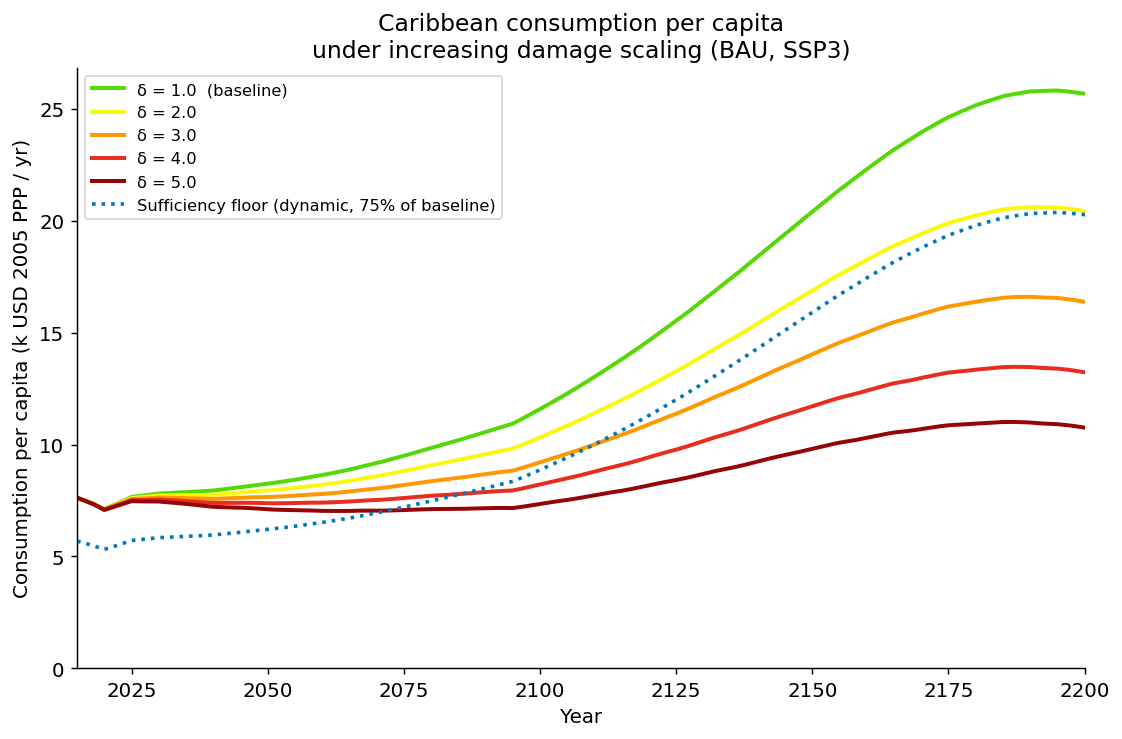

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for delta, ds in delta_results.items():
    try:
        r_idx = region_idx('rcam')
        cpc   = np.squeeze(ds['consumption_per_capita'])
        if cpc.ndim > 2: cpc = cpc[0]
        ax.plot(years, cpc[r_idx],
                color=DELTA_COLOURS[delta], linewidth=2.2,
                label=f'δ = {delta}{"  (baseline)" if delta == 1.0 else ""}',
                linestyle='-')
    except Exception:
        pass

ax.plot(years, SUFFICIENCY_THR_DYNAMIC, color=C_CARIB, linewidth=2, linestyle=':',
        label='Sufficiency floor (dynamic, 75% of baseline)')

ax.set_xlim(2015, 2200)
ax.set_ylim(bottom=0)
ax.set_xlabel('Year')
ax.set_ylabel('Consumption per capita (k USD 2005 PPP / yr)')
ax.set_title('Caribbean consumption per capita\nunder increasing damage scaling (BAU, SSP3)')
ax.legend(fontsize=9)


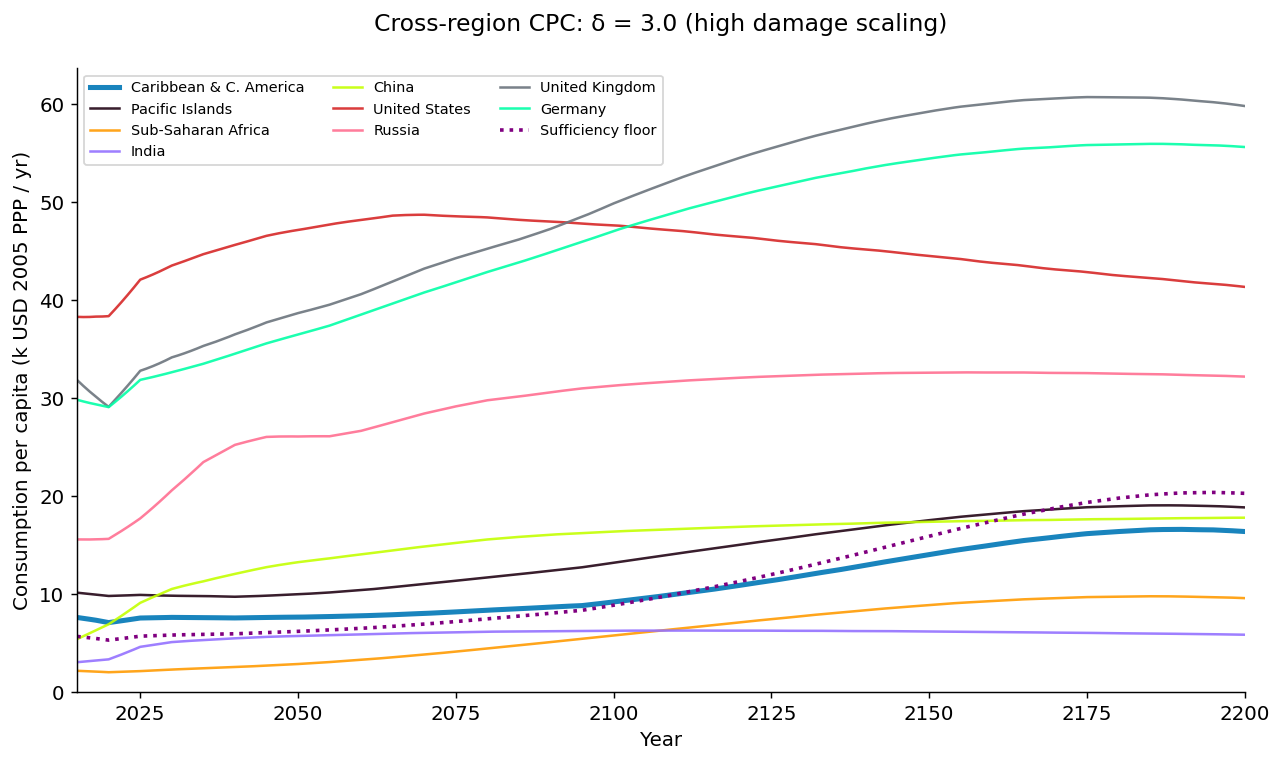

Saved: caricom_09_delta_cross_region.png


In [ ]:
delta_hi     = 3.0
ds_hi_delta  = delta_results[delta_hi]

fig2, ax3 = plt.subplots(figsize=(10, 6))
for code, name in FOCUS_REGIONS.items():
    try:
        r_idx = region_idx(code)
        cpc   = np.squeeze(ds_hi_delta['consumption_per_capita'])
        if cpc.ndim > 2: cpc = cpc[0]
        color  = C_CARIB   if code == 'rcam'   else \
                 C_EXTRA2  if code == 'rfa' else \
                 C_EXTRA3  if code == 'rus' else \
                 C_EXTRA4  if code == 'nde' else \
                 C_DANGER  if code == 'usa' else \
                 C_EXTRA5  if code == 'chn' else \
                 C_EXTRA6  if code == 'rsaf' else \
                 C_EXTRA7  if code == 'rjan57' else \
                 C_NEUTRAL
        lw    = 2.8 if code == 'rcam' else 1.4
        ls    = '-'  if code == 'rcam' else '-.'
        ax3.plot(years, cpc[r_idx], color=color, linewidth=lw,
                 linestyle='-', label=name, alpha=0.9)
    except Exception:
        pass

ax3.plot(years, SUFFICIENCY_THR_DYNAMIC, color='purple', linewidth=2, linestyle=':',
         label=f'Sufficiency floor')
ax3.set_xlim(2015, 2200)
ax3.set_ylim(bottom=0)
ax3.set_xlabel('Year')
ax3.set_ylabel('Consumption per capita (k USD 2005 PPP / yr)')
ax3.set_title(
    f'Cross-region CPC: \u03b4 = {delta_hi} (high damage scaling)\n')
ax3.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_09_delta_cross_region.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_09_delta_cross_region.png')

---
### Reading the cross-region chart (δ = 3.0)

The Caribbean (`rcam`, thick blue) starts below almost every other region and remains near the bottom throughout the projection period. Even by 2200, after centuries of modelled economic growth, it is still one of the lowest-consuming regions. Comparing it to the UK, Germany, and the US, they are orders of magnitude higher.

The dashed pink line marks the Caribbean's **2024 average CPC**. Under δ = 3.0 BAU, the Caribbean does not recover to its own 2024 income level until approximately 2075-2100, meaning it takes 50-75 years simply to return to where it stands today. This is the model's quantification of the "lost decades" argument that underpins CARICOM's Loss & Damage claims.


---
## Part 12: Debate evidence card

This cell extracts the key quantitative findings from all previous parts and prints them as a structured reference card for use in the COP31 negotiation. All numbers are model outputs from JUSTICE; citations for empirical calibration choices are noted inline.


In [ ]:
# Extract key numbers
try:
    r_idx_carib = region_idx('rcam')

    # Temperature
    t_bau   = float(np.max(np.squeeze(ds_bau['global_temperature'])))
    t_hi    = float(np.max(np.squeeze(ds_hi['global_temperature'])))

    # Years above thresholds
    yat15_bau = float(years_above_temperature_threshold(ds_bau['global_temperature'], 1.5))
    yat15_hi  = float(years_above_temperature_threshold(ds_hi['global_temperature'], 1.5))
    yat20_bau = float(years_above_temperature_threshold(ds_bau['global_temperature'], 2.0))
    yat20_hi  = float(years_above_temperature_threshold(ds_hi['global_temperature'], 2.0))

    # Caribbean consumption at 2100
    cpc_carib_bau = float(np.squeeze(ds_bau['consumption_per_capita'])[r_idx_carib, 2100-2015])
    cpc_carib_hi  = float(np.squeeze(ds_hi['consumption_per_capita'])[r_idx_carib, 2100-2015])

    # Damage fraction at 2100
    dmg_frac_carib_bau = float(
        np.squeeze(ds_bau.get('damage_fraction',
            np.squeeze(ds_bau['economic_damage']) / np.squeeze(ds_bau['gross_economic_output'])))
        [r_idx_carib, 2100-2015]) * 100

    # Robustness score at ECR=0.90
    if 'rob_by_ecr' in dir() and len(rob_by_ecr) > 0:
        ecr_090 = rob_by_ecr[rob_by_ecr['ecr'].round(2) == 0.90]
        rob_score_suff = float(ecr_090['sufficiency_robustness'].iloc[0]) if len(ecr_090) > 0 else float('nan')
        rob_score_temp = float(ecr_090['temp_robustness'].iloc[0]) if len(ecr_090) > 0 else float('nan')
    else:
        rob_score_suff = rob_score_temp = float('nan')

except Exception as e:
    print(f'Warning extracting card numbers: {e}')
    t_bau = t_hi = yat15_bau = yat15_hi = yat20_bau = yat20_hi = float('nan')
    cpc_carib_bau = cpc_carib_hi = dmg_frac_carib_bau = float('nan')
    rob_score_suff = rob_score_temp = float('nan')

# Print evidence card
card = [
    ('Actor',                            'CARICOM (Caribbean Community)'),
    ('Bloc',                             'Bloc 1: Existential Frontline'),
    ('Welfare function chosen',          'SUFFICIENTARIAN'),
    ('Why this function fits',           'No region should fall below the survival threshold;\n'
                                         'mirrors the Loss & Damage argument: the harm to\n'
                                         'the Caribbean cannot be traded off against global gains'),
    ('Key region',                       'rcam (Rest of Central America & Caribbean)'),
    ('',                                 ''),
    ('MODEL EVIDENCE', ''),
    ('Peak temperature BAU',             f'{t_bau:.2f}°C'),
    ('Peak temperature high-ambition',   f'{t_hi:.2f}°C'),
    ('Years above 1.5°C (BAU)',          f'{yat15_bau:.0f} years'),
    ('Years above 1.5°C (high-amb)',     f'{yat15_hi:.0f} years'),
    ('Years above 2.0°C (BAU)',          f'{yat20_bau:.0f} years'),
    ('Caribbean damage fraction 2100 (BAU)', f'{dmg_frac_carib_bau:.2f}% of GDP'),
    ('Caribbean consumption 2100 (BAU)',   f'{cpc_carib_bau:.4f} k USD/cap/yr'),
    ('Caribbean consumption 2100 (hi-amb)',f'{cpc_carib_hi:.4f} k USD/cap/yr'),
    ('Sufficiency robustness (ECR=0.9)', f'{rob_score_suff:.0%}'),
    ('Temperature robustness (ECR=0.9)', f'{rob_score_temp:.0%}'),
    ('',                                 ''),
    ('NEGOTIATING POSITIONS', ''),
    ('Satisficing criterion',  'Caribbean CPC ≥ dynamic sufficiency floor at ALL timesteps\n'
                           'AND global temperature ≤ 1.5°C at 2100'),
    ('Absolute red line',                'No agreement without binding 1.5°C pathway\n'
                                         'AND a Loss and Damage fund (grant-based, not loans)'),
    ('Minimum condition for yes',        '1.5°C target enshrined + L&D fund operational\n'
                                         'before 2030 + differentiated abatement (CBDR-RC)'),
    ('Rival welfare function',           'UTILITARIAN shows how global aggregation\n'
                                         'can mask Caribbean devastation'),
    ('Key political argument',           'Historical responsibility: the Caribbean\n'
                                         'contributed <0.1% of cumulative emissions\n'
                                         'yet faces existential climate risk. Developed\n'
                                         'nations must carry the abatement burden.'),
]

print('  CARICOM DEBATE EVIDENCE CARD')
print('  COP31 | EPA141A | JUSTICE Model')
print('=' * 100)
for key, val in card:
    if key.startswith('──'):
        print(f'\n{key}')
    elif key == '':
        print()
    else:
        val_lines = val.split('\n')
        print(f'  {key:<42s} {val_lines[0]}')
        for extra in val_lines[1:]:
            print(f'  {"":<42s} {extra}')

  CARICOM DEBATE EVIDENCE CARD
  COP31 | EPA141A | JUSTICE Model
  Actor                                      CARICOM (Caribbean Community)
  Bloc                                       Bloc 1: Existential Frontline
  Welfare function chosen                    SUFFICIENTARIAN
  Why this function fits                     No region should fall below the survival threshold;
                                             mirrors the Loss & Damage argument: the harm to
                                             the Caribbean cannot be traded off against global gains
  Key region                                 rcam (Rest of Central America & Caribbean)

  MODEL EVIDENCE                             
  Peak temperature BAU                       6.55°C
  Peak temperature high-ambition             2.97°C
  Years above 1.5°C (BAU)                    274 years
  Years above 1.5°C (high-amb)               258 years
  Years above 2.0°C (BAU)                    257 years
  Caribbean damage fraction 2

---
## Part 13: Summary figure

A single six-panel figure consolidating the core evidence: temperature trajectories, Caribbean damage fraction, consumption per capita with sufficiency floor, robustness by ECR, welfare function comparison, and a printed evidence card. Intended as a one-page visual summary for the negotiation.


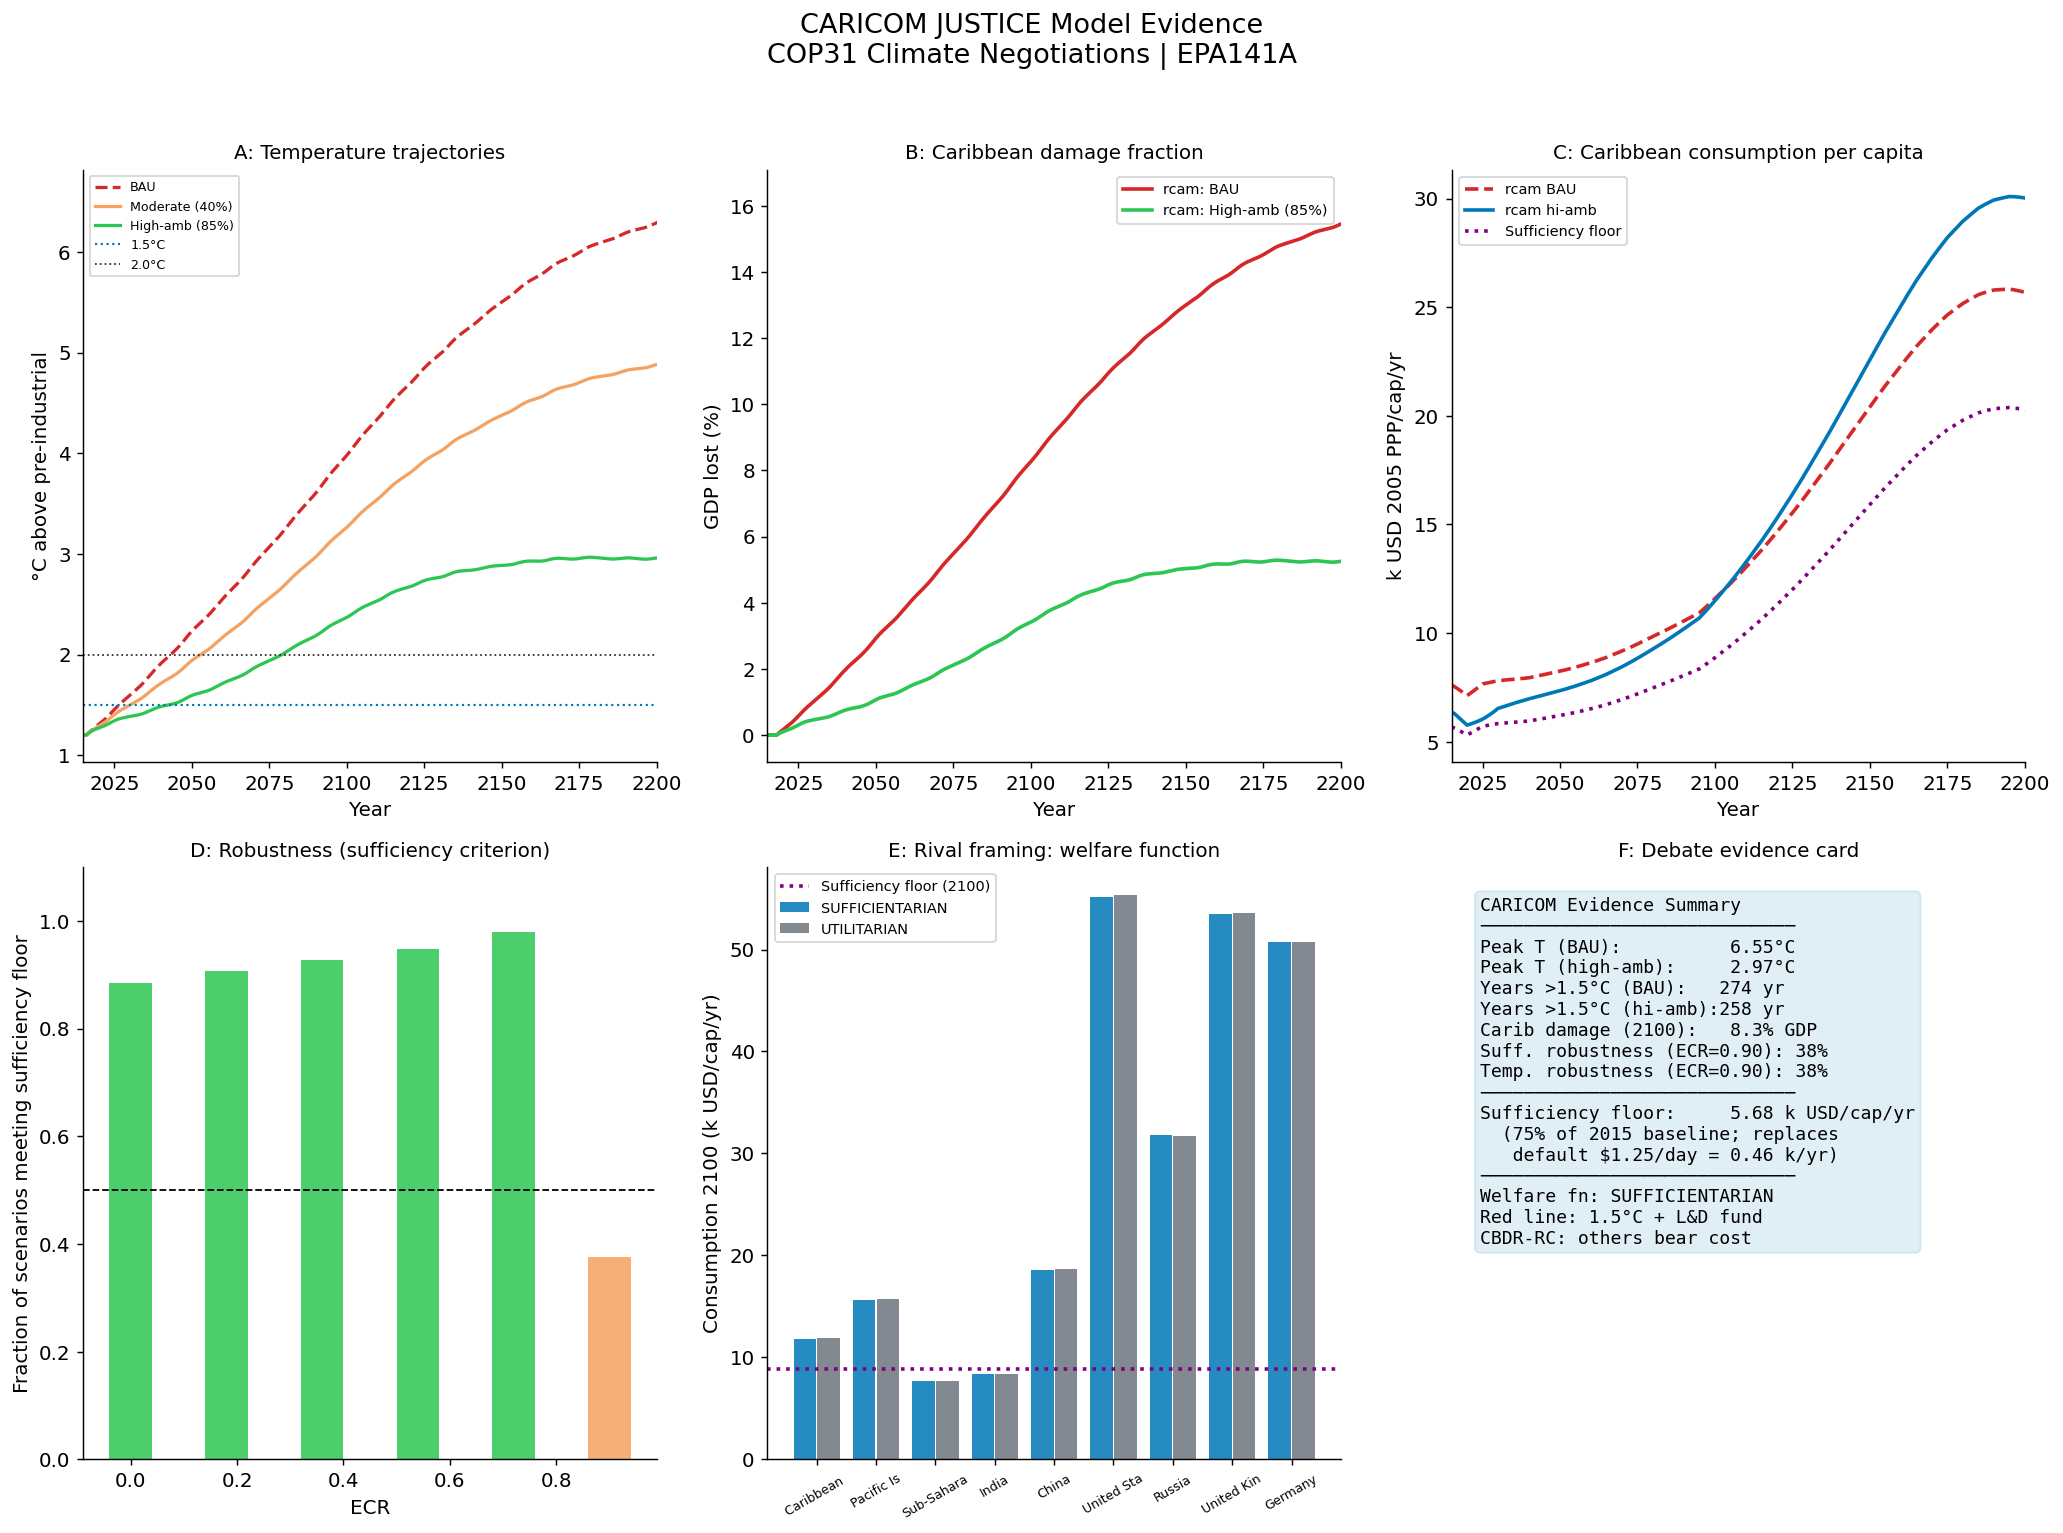

Saved: caricom_00_summary.png

All plots saved to: c:\Users\charl\epa141a-main\assignments_ema\plots_caricom


In [ ]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('CARICOM JUSTICE Model Evidence\nCOP31 Climate Negotiations | EPA141A',
             fontsize=15, y=0.98)

# Panel A: Temperature 
ax_a = fig.add_subplot(2, 3, 1)
for label, ds, color, ls in [
    ('BAU',           ds_bau, C_DANGER, '--'),
    ('Moderate (40%)', ds_mod, C_WARN,   '-'),
    ('High-amb (85%)', ds_hi,  C_SAFE,   '-'),
]:
    ax_a.plot(years, np.squeeze(ds['global_temperature']),
              color=color, linestyle=ls, linewidth=1.8, label=label)
ax_a.axhline(1.5, color=C_CARIB,  linewidth=1.2, linestyle=':', label='1.5°C')
ax_a.axhline(2.0, color='#333333', linewidth=1.0, linestyle=':', label='2.0°C')
ax_a.set_xlim(2015, 2200)
ax_a.set_title('A: Temperature trajectories', fontsize=11)
ax_a.set_xlabel('Year'); ax_a.set_ylabel('°C above pre-industrial')
ax_a.legend(fontsize=7)

# Panel B: Damage fraction for Caribbean 
ax_b = fig.add_subplot(2, 3, 2)
r_carib = region_idx('rcam') if 'rcam' in list(REGION_LIST) else 0
for label, ds, color in [
    ('BAU',           ds_bau, C_DANGER),
    ('High-amb (85%)', ds_hi,  C_SAFE),
]:
    dmg_frac = np.squeeze(ds.get('damage_fraction',
                np.squeeze(ds['economic_damage']) / np.squeeze(ds['gross_economic_output'])))
    if dmg_frac.ndim > 2: dmg_frac = dmg_frac[0]
    ax_b.plot(years, dmg_frac[r_carib]*100, color=color, linewidth=2, label=f'rcam: {label}')
ax_b.set_title('B: Caribbean damage fraction', fontsize=11)
ax_b.set_xlabel('Year'); ax_b.set_ylabel('GDP lost (%)')
ax_b.set_xlim(2015, 2200); ax_b.legend(fontsize=8)

# Panel C: Consumption per capita 
ax_c = fig.add_subplot(2, 3, 3)
for label, ds, color, ls in [
    ('rcam BAU',      ds_bau, C_DANGER, '--'),
    ('rcam hi-amb',   ds_hi,  C_CARIB,  '-'),
]:
    cpc = np.squeeze(ds['consumption_per_capita'])
    if cpc.ndim > 2: cpc = cpc[0]
    ax_c.plot(years, cpc[r_carib], color=color, linestyle=ls, linewidth=2, label=label)
ax_c.plot(years, SUFFICIENCY_THR_DYNAMIC, color='purple', linewidth=2, linestyle=':',
          label=f'Sufficiency floor')
ax_c.set_title('C: Caribbean consumption per capita', fontsize=11)
ax_c.set_xlabel('Year'); ax_c.set_ylabel('k USD 2005 PPP/cap/yr')
ax_c.set_xlim(2015, 2200); ax_c.legend(fontsize=8)

# Panel D: Robustness bar chart 
ax_d = fig.add_subplot(2, 3, 4)
if 'rob_by_ecr' in dir() and len(rob_by_ecr) > 0:
    bar_colors = [C_SAFE if v >= 0.5 else C_WARN if v >= 0.25 else C_DANGER
                  for v in rob_by_ecr['sufficiency_robustness'].values]
    ax_d.bar(rob_by_ecr['ecr'], rob_by_ecr['sufficiency_robustness'],
             width=0.08, color=bar_colors, alpha=0.85)
    ax_d.axhline(0.5, color='black', linewidth=1, linestyle='--')
    ax_d.set_ylim(0, 1.1)
    ax_d.set_xlabel('ECR')
ax_d.set_title('D: Robustness (sufficiency criterion)', fontsize=11)
ax_d.set_ylabel('Fraction of scenarios meeting sufficiency floor')

# Panel E: Welfare function comparison 
ax_e = fig.add_subplot(2, 3, 5)
if 'df_rival' in dir() and len(df_rival) > 0:
    x_e = np.arange(len(df_rival))
    ax_e.bar(x_e - 0.2, df_rival['SUFFICIENTARIAN'], 0.38,
             label='SUFFICIENTARIAN', color=C_CARIB, alpha=0.85)
    ax_e.bar(x_e + 0.2, df_rival['UTILITARIAN'],     0.38,
             label='UTILITARIAN',     color=C_NEUTRAL, alpha=0.85)
    ax_e.axhline(SUFFICIENCY_THR_DYNAMIC[2100-2015], color='purple', linewidth=2, linestyle=':',
             label='Sufficiency floor (2100)')
    ax_e.set_xticks(x_e)
    ax_e.set_xticklabels([r[:10] for r in df_rival.index], rotation=30, fontsize=7)
    ax_e.legend(fontsize=8)
ax_e.set_title('E: Rival framing: welfare function', fontsize=11)
ax_e.set_ylabel('Consumption 2100 (k USD/cap/yr)')

# Panel F: Key numbers text box 
ax_f = fig.add_subplot(2, 3, 6)
ax_f.axis('off')
card_text = (
    'CARICOM Evidence Summary\n'
    '─────────────────────────────\n'
    f'Peak T (BAU):          {t_bau:.2f}°C\n'
    f'Peak T (high-amb):     {t_hi:.2f}°C\n'
    f'Years >1.5°C (BAU):   {yat15_bau:.0f} yr\n'
    f'Years >1.5°C (hi-amb):{yat15_hi:.0f} yr\n'
    f'Carib damage (2100):   {dmg_frac_carib_bau:.1f}% GDP\n'
    f'Suff. robustness (ECR=0.90): {rob_score_suff:.0%}\n'
    f'Temp. robustness (ECR=0.90): {rob_score_temp:.0%}\n'
    '─────────────────────────────\n'
    f'Sufficiency floor:     {SUFFICIENCY_THR:.2f} k USD/cap/yr\n'
    f'  (75% of 2015 baseline; replaces\n'
    f'   default $1.25/day = 0.46 k/yr)\n'
    '─────────────────────────────\n'
    'Welfare fn: SUFFICIENTARIAN\n'
    'Red line: 1.5°C + L&D fund\n'
    'CBDR-RC: others bear cost'
)
ax_f.text(0.05, 0.95, card_text, transform=ax_f.transAxes,
          fontsize=10, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor=C_CARIB, alpha=0.12, edgecolor=C_CARIB))
ax_f.set_title('F: Debate evidence card', fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(_PLOTS_DIR, 'caricom_00_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: caricom_00_summary.png')
print(f'\nAll plots saved to: {_PLOTS_DIR}')